인보응 프로젝트
1차 실험 결과

전반적으로 적응형 위험 토큰 사전 기반 URL 분류 구조가 정상적으로 동작했으나, phishing 클래스의 F1-score가 0.76으로 다른 클래스에 비해 낮게 나타남.
특히 recall은 비교적으로 높으나, precision이 0.67에 머물렀음. 이는 모델이 phishing URL을 놓치는 문제보다는, 정상 URL을 phishing으로 잘못 분류하는 오탐이 많다는 것을 의미함.
이 결과는 phishing URL이 malware나 defacement URL처럼 명확한 악성 문자열 패턴을 갖기보다는, 정상 서비스에서도 자주 등장하는 토큰을 공유하는 경향이 있기 때문으로 해석할 수 있음.
즉, phishing URL은 정상 URL과 토큰 분포가 상대적으로 유사하여 단순한 위험 토큰 사전 기반 feature만으로는 구분이 어려움. 
추후 phishing 클래스에 대해 더 보수적인 decision threshold를 적용하거나, benign-phishing 간 확률 margin을 고려하는 방식, 또는 도메인 유사도나 브랜드 사칭 여부, URL 구조적 위장 패턴과 같은 phishing 특화 feature를 추가하는 방향으로 개선할 필요가 있음.

In [1]:
# ============================================================
# AI-based Multi-Class Malicious URL Detection
# Adaptive Risk Token Dictionary + Streaming Update
# Safe Full Version
# ============================================================

import os
import re
import json
import math
import urllib.parse
from collections import Counter, deque

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 0. Config
# ============================================================

SEED = 42
np.random.seed(SEED)

DATA_PATH = "./malicious_phish.csv"

URL_COL = "url"
LABEL_COL = "type"
BENIGN_LABEL = "benign"

# Risk dictionary
TOP_K_COMMON_MALICIOUS = 1000
TOP_K_PER_MAL_CLASS = 800
MIN_TOKEN_DF = 5
MIN_MAL_CLASSES_FOR_COMMON = 2
ALPHA = 1.0

# TF-IDF
MAX_TFIDF_FEATURES = 50000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Streaming
BATCH_SIZE = 5000
UPDATE_INTERVAL = 3
SLIDING_WINDOW_BATCHES = 6

# Output
RISK_DICT_DIR = "./risk_dict"
RESULT_DIR = "./results"

os.makedirs(RISK_DICT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


# ============================================================
# 1. Safe URL Tokenizer
# ============================================================

def clean_url_text(url):
    """
    어떤 URL 문자열이 들어와도 urlparse가 죽지 않도록 정리.
    특히 Invalid IPv6 URL을 유발하는 '[' ']' 제거.
    """
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    # Invalid IPv6 URL 에러 방지 핵심
    url = url.replace("[", "")
    url = url.replace("]", "")

    # 제어 문자 제거
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    """
    URL 내부 문자열을 특수문자 기준으로 분리.
    """
    if text is None:
        return []

    text = clean_url_text(text)

    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def char_ngrams(token, n_min=3, n_max=4):
    """
    긴 문자열에 대해 character n-gram 생성.
    """
    token = str(token).lower()
    grams = []

    if len(token) < n_min:
        return grams

    for n in range(n_min, n_max + 1):
        if len(token) >= n:
            for i in range(len(token) - n + 1):
                grams.append(f"char:{token[i:i+n]}")

    return grams


def safe_parse_url(url):
    """
    urlparse를 안전하게 수행.
    실패하면 invalid.local로 대체.
    이 함수는 절대 에러를 밖으로 던지지 않음.
    """
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        try:
            return urllib.parse.urlparse("http://invalid.local/")
        except Exception:
            # 이론상 거의 도달하지 않지만 완전 방어용
            return None


def tokenize_url(url):
    """
    URL 구조 기반 보안 특화 tokenizer.
    어떤 URL이 들어와도 절대 예외를 밖으로 던지지 않음.
    """
    try:
        decoded_url = clean_url_text(url)
        parsed = safe_parse_url(decoded_url)

        tokens = []

        if parsed is None:
            general_parts = split_by_separators(decoded_url)
            for p in general_parts:
                tokens.append(f"tok:{p}")
            return tokens if tokens else ["empty_or_invalid_url"]

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        # user:pass@host
        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        # port 제거
        if ":" in host:
            host = host.split(":")[0]

        # www 제거
        if host.startswith("www."):
            host = host[4:]

        # IP host 여부
        if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
            tokens.append("host_is_ip")

        # domain / subdomain / tld
        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tld = domain_parts[-1]
            tokens.append(f"tld:{tld}")

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 1:
                    tokens.append(f"tldpart:{part}")
                elif idx == len(domain_parts) - 2:
                    tokens.append(f"sld:{part}")
                else:
                    tokens.append(f"subdomain:{part}")

                tokens.append(f"domain:{part}")

                for sub in split_by_separators(part):
                    tokens.append(f"dpart:{sub}")

        # path
        path_segments = [seg for seg in path.split("/") if seg]

        for seg in path_segments:
            tokens.append(f"path:{seg}")

            for p in split_by_separators(seg):
                tokens.append(f"pseg:{p}")

        # extension
        if path_segments:
            last_seg = path_segments[-1]
            if "." in last_seg:
                ext = last_seg.split(".")[-1]
                if 1 <= len(ext) <= 8:
                    tokens.append(f"ext:{ext}")

        # query
        if query:
            tokens.append("has_query")

        try:
            query_pairs = urllib.parse.parse_qsl(query, keep_blank_values=True)
        except Exception:
            query_pairs = []

        for k, v in query_pairs:
            if k:
                tokens.append(f"qkey:{k}")
                for p in split_by_separators(k):
                    tokens.append(f"qk:{p}")

            if v:
                for p in split_by_separators(v):
                    tokens.append(f"qv:{p}")

        # 전체 URL 기준 일반 토큰
        general_parts = split_by_separators(decoded_url)

        for p in general_parts:
            tokens.append(f"tok:{p}")

        # 긴 문자열에 character n-gram 추가
        for p in general_parts:
            if len(p) >= 6:
                tokens.extend(char_ngrams(p, 3, 4))

        # 구조적 패턴 토큰
        if "-" in decoded_url:
            tokens.append("has_hyphen")
        if "_" in decoded_url:
            tokens.append("has_underscore")
        if "%" in decoded_url:
            tokens.append("has_percent_encoding")
        if decoded_url.count(".") >= 4:
            tokens.append("many_dots")
        if len(decoded_url) >= 100:
            tokens.append("very_long_url")

        if not tokens:
            tokens.append("empty_or_invalid_url")

        return tokens

    except Exception:
        return ["tokenizer_error"]


def safe_tokenize(url):
    """
    외부에서 항상 이 tokenizer를 사용.
    """
    try:
        return tokenize_url(url)
    except Exception:
        return ["tokenizer_error"]


# tokenizer 작동 테스트
test_urls = [
    "https://secure-login.example.com/account/verify?id=123",
    "http://abc.ru/download/app.apk",
    "paypal.com.verify-user-login-security.com/index.php",
    "http://[broken-ipv6-url",
    "[invalid]url.com/test"
]

print("Tokenizer test:")
for u in test_urls:
    print(u, "=>", safe_tokenize(u)[:20])


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())


# ============================================================
# 3. Split: Initial Train 50% / Stream Update 30% / Final Test 20%
# ============================================================

initial_train_df, temp_df = train_test_split(
    df,
    test_size=0.50,
    stratify=df[LABEL_COL],
    random_state=SEED
)

stream_update_df, final_test_df = train_test_split(
    temp_df,
    test_size=0.40,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print("\nSplit result")
print("Initial Train:", initial_train_df.shape)
print("Stream Update:", stream_update_df.shape)
print("Final Test:", final_test_df.shape)

print("\nInitial Train label distribution")
print(initial_train_df[LABEL_COL].value_counts())

print("\nStream Update label distribution")
print(stream_update_df[LABEL_COL].value_counts())

print("\nFinal Test label distribution")
print(final_test_df[LABEL_COL].value_counts())


# ============================================================
# 4. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_initial = label_encoder.fit_transform(initial_train_df[LABEL_COL])
y_stream = label_encoder.transform(stream_update_df[LABEL_COL])
y_final = label_encoder.transform(final_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
malicious_classes = [c for c in class_names if c != BENIGN_LABEL]
all_class_ids = np.arange(len(class_names))

print("\nClass names:", class_names)
print("Malicious classes:", malicious_classes)


# ============================================================
# 5. Adaptive Risk Token Dictionary
# ============================================================

def build_adaptive_risk_dictionary(
    urls,
    labels,
    tokenizer,
    class_names,
    benign_label="benign",
    top_k_common=1000,
    top_k_per_class=800,
    min_df=5,
    min_mal_classes_for_common=2,
    alpha=1.0
):
    """
    위험 토큰 사전 생성.

    common_malicious:
        benign에서는 적게 나오고,
        여러 악성 클래스에서 공통적으로 많이 나오는 토큰.

    class_specific:
        특정 악성 클래스에서 다른 클래스보다 더 강하게 나타나는 토큰.
    """

    malicious_classes = [c for c in class_names if c != benign_label]

    class_token_df = {c: Counter() for c in class_names}
    total_token_df = Counter()
    class_doc_count = Counter()

    for url, label in zip(urls, labels):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        class_doc_count[label] += 1

        for t in tokens:
            class_token_df[label][t] += 1
            total_token_df[t] += 1

    total_docs = sum(class_doc_count.values())
    benign_docs = class_doc_count[benign_label]
    malicious_docs = total_docs - benign_docs

    # --------------------------------------------------------
    # 5-1. Common malicious tokens
    # --------------------------------------------------------
    common_scores = {}

    for token, total_df in total_token_df.items():
        if total_df < min_df:
            continue

        benign_df = class_token_df[benign_label][token]
        malicious_df = sum(class_token_df[c][token] for c in malicious_classes)

        mal_class_presence = sum(
            1 for c in malicious_classes
            if class_token_df[c][token] > 0
        )

        if mal_class_presence < min_mal_classes_for_common:
            continue

        p_token_mal = (malicious_df + alpha) / (malicious_docs + 2 * alpha)
        p_token_benign = (benign_df + alpha) / (benign_docs + 2 * alpha)

        score = math.log(p_token_mal / p_token_benign)

        if score > 0:
            common_scores[token] = score

    common_malicious = dict(
        sorted(common_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_common]
    )

    # --------------------------------------------------------
    # 5-2. Class-specific malicious tokens
    # --------------------------------------------------------
    class_specific = {c: {} for c in malicious_classes}

    for c in malicious_classes:
        scores = {}

        n_c = class_doc_count[c]
        n_not_c = total_docs - n_c

        for token, total_df in total_token_df.items():
            if total_df < min_df:
                continue

            df_c = class_token_df[c][token]
            df_not_c = total_df - df_c

            p_token_c = (df_c + alpha) / (n_c + 2 * alpha)
            p_token_not_c = (df_not_c + alpha) / (n_not_c + 2 * alpha)

            score = math.log(p_token_c / p_token_not_c)

            if score > 0:
                scores[token] = score

        class_specific[c] = dict(
            sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_class]
        )

    return {
        "common_malicious": common_malicious,
        "class_specific": class_specific
    }


def save_risk_dict(risk_dict, version):
    path = os.path.join(RISK_DICT_DIR, f"risk_token_dict_v{version}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(risk_dict, f, ensure_ascii=False, indent=2)
    print(f"Saved risk dictionary: {path}")


def print_risk_dict_preview(risk_dict, top_n=15):
    print("\n===== Common Malicious Risk Tokens =====")
    for token, score in list(risk_dict["common_malicious"].items())[:top_n]:
        print(token, round(score, 4))

    print("\n===== Class-specific Risk Tokens =====")
    for c, d in risk_dict["class_specific"].items():
        print(f"\n[{c}]")
        for token, score in list(d.items())[:top_n]:
            print(token, round(score, 4))


# ============================================================
# 6. Build Initial Risk Dictionary
# ============================================================

print("\nBuilding initial risk dictionary...")

initial_urls = initial_train_df[URL_COL].tolist()
initial_labels = initial_train_df[LABEL_COL].tolist()

risk_dict = build_adaptive_risk_dictionary(
    urls=initial_urls,
    labels=initial_labels,
    tokenizer=safe_tokenize,
    class_names=class_names,
    benign_label=BENIGN_LABEL,
    top_k_common=TOP_K_COMMON_MALICIOUS,
    top_k_per_class=TOP_K_PER_MAL_CLASS,
    min_df=MIN_TOKEN_DF,
    min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
    alpha=ALPHA
)

save_risk_dict(risk_dict, version=0)
print_risk_dict_preview(risk_dict, top_n=20)


# ============================================================
# 7. Feature Engineering
# ============================================================

def risk_score_features(urls, risk_dict, tokenizer, malicious_classes):
    """
    URL 하나를 위험 토큰 사전 기반 feature로 변환.

    feature 구성:
    - common malicious score
    - common malicious match count
    - 각 악성 클래스별 score
    - 각 악성 클래스별 match count
    """
    rows = []

    common_dict = risk_dict["common_malicious"]
    class_dict = risk_dict["class_specific"]

    for url in urls:
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        row = []

        common_score = 0.0
        common_count = 0

        for t in tokens:
            if t in common_dict:
                common_score += common_dict[t]
                common_count += 1

        row.append(common_score)
        row.append(common_count)

        for c in malicious_classes:
            c_score = 0.0
            c_count = 0

            c_dict = class_dict.get(c, {})

            for t in tokens:
                if t in c_dict:
                    c_score += c_dict[t]
                    c_count += 1

            row.append(c_score)
            row.append(c_count)

        rows.append(row)

    return np.array(rows, dtype=np.float32)


def lexical_features(urls):
    """
    URL 구조 통계 feature.
    """
    rows = []

    for url in urls:
        u = clean_url_text(url)
        length = len(u)

        digit_count = sum(ch.isdigit() for ch in u)
        alpha_count = sum(ch.isalpha() for ch in u)
        special_count = sum(not ch.isalnum() for ch in u)

        dot_count = u.count(".")
        slash_count = u.count("/")
        hyphen_count = u.count("-")
        underscore_count = u.count("_")
        question_count = u.count("?")
        equal_count = u.count("=")
        amp_count = u.count("&")
        percent_count = u.count("%")
        at_count = u.count("@")

        digit_ratio = digit_count / max(length, 1)
        alpha_ratio = alpha_count / max(length, 1)
        special_ratio = special_count / max(length, 1)

        has_ip = 1 if re.search(r"\d{1,3}(\.\d{1,3}){3}", u) else 0
        has_https = 1 if u.startswith("https://") else 0
        has_http = 1 if u.startswith("http://") else 0

        rows.append([
            length,
            digit_count,
            alpha_count,
            special_count,
            dot_count,
            slash_count,
            hyphen_count,
            underscore_count,
            question_count,
            equal_count,
            amp_count,
            percent_count,
            at_count,
            digit_ratio,
            alpha_ratio,
            special_ratio,
            has_ip,
            has_https,
            has_http
        ])

    return np.array(rows, dtype=np.float32)


def build_train_features(urls, risk_dict, malicious_classes):
    """
    Initial train용 feature 생성.
    TF-IDF vectorizer와 scaler는 initial train에 대해서만 fit.
    """
    vectorizer = TfidfVectorizer(
        tokenizer=safe_tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_TFIDF_FEATURES,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF
    )

    X_tfidf = vectorizer.fit_transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])

    scaler = StandardScaler()
    X_extra_scaled = scaler.fit_transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X, vectorizer, scaler


def build_eval_features(urls, risk_dict, malicious_classes, vectorizer, scaler):
    """
    Stream/Test용 feature 생성.
    vectorizer와 scaler는 initial train에서 fit한 것을 그대로 사용.
    """
    X_tfidf = vectorizer.transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])
    X_extra_scaled = scaler.transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X


# ============================================================
# 8. Initial Model Training
# ============================================================

print("\nBuilding initial features...")

X_initial, vectorizer, scaler = build_train_features(
    urls=initial_train_df[URL_COL].tolist(),
    risk_dict=risk_dict,
    malicious_classes=malicious_classes
)

print("X_initial shape:", X_initial.shape)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=1,
    tol=None,
    random_state=SEED,
    n_jobs=-1
)

initial_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_initial
)

model.partial_fit(
    X_initial,
    y_initial,
    classes=all_class_ids,
    sample_weight=initial_sample_weight
)

print("\nInitial model trained.")


# ============================================================
# 9. Evaluation Function
# ============================================================

def evaluate_model(
    model,
    urls,
    y_true,
    risk_dict,
    malicious_classes,
    vectorizer,
    scaler,
    title="Evaluation",
    verbose=True
):
    X = build_eval_features(
        urls=urls,
        risk_dict=risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=vectorizer,
        scaler=scaler
    )

    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    if verbose:
        print(f"\n===== {title} =====")
        print("Accuracy:", round(acc, 4))
        print("Macro-F1:", round(macro_f1, 4))
        print("Weighted-F1:", round(weighted_f1, 4))
        print("\nClassification Report")
        print(classification_report(y_true, y_pred, target_names=class_names))
        print("\nConfusion Matrix")
        print(confusion_matrix(y_true, y_pred))

    return {
        "title": title,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


# ============================================================
# 10. Stream Utility Functions
# ============================================================

def make_batches(df, batch_size):
    batches = []

    n = len(df)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batches.append(df.iloc[start:end].copy())

    return batches


def summarize_risk_dict_change(old_dict, new_dict, malicious_classes):
    summary = {}

    old_common = set(old_dict["common_malicious"].keys())
    new_common = set(new_dict["common_malicious"].keys())

    summary["common_malicious"] = {
        "added": len(new_common - old_common),
        "removed": len(old_common - new_common),
        "kept": len(old_common & new_common),
        "sample_added": list(new_common - old_common)[:10],
        "sample_removed": list(old_common - new_common)[:10]
    }

    for c in malicious_classes:
        old_tokens = set(old_dict["class_specific"].get(c, {}).keys())
        new_tokens = set(new_dict["class_specific"].get(c, {}).keys())

        summary[c] = {
            "added": len(new_tokens - old_tokens),
            "removed": len(old_tokens - new_tokens),
            "kept": len(old_tokens & new_tokens),
            "sample_added": list(new_tokens - old_tokens)[:10],
            "sample_removed": list(old_tokens - new_tokens)[:10]
        }

    return summary


def print_change_summary(summary):
    print("\nRisk Dictionary Change Summary")

    for key, value in summary.items():
        print(f"\n[{key}]")
        print("added:", value["added"])
        print("removed:", value["removed"])
        print("kept:", value["kept"])
        print("sample_added:", value["sample_added"])
        print("sample_removed:", value["sample_removed"])


# ============================================================
# 11. Streaming Update
# ============================================================

stream_batches = make_batches(stream_update_df, BATCH_SIZE)

print("\nNumber of stream batches:", len(stream_batches))
print("Batch size:", BATCH_SIZE)
print("Update interval:", UPDATE_INTERVAL)
print("Sliding window batches:", SLIDING_WINDOW_BATCHES)

current_model = model
current_risk_dict = risk_dict
current_vectorizer = vectorizer
current_scaler = scaler

recent_stream_buffer = deque(maxlen=SLIDING_WINDOW_BATCHES)

stream_results = []
version = 0

for batch_idx, batch_df in enumerate(stream_batches, start=1):
    print(f"\n\n========== Stream Batch {batch_idx}/{len(stream_batches)} ==========")

    recent_stream_buffer.append(batch_df)

    batch_urls = batch_df[URL_COL].tolist()
    batch_y = label_encoder.transform(batch_df[LABEL_COL])

    # 현재 모델로 stream batch 평가
    # Final Test는 여기서 사용하지 않음.
    batch_result = evaluate_model(
        model=current_model,
        urls=batch_urls,
        y_true=batch_y,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler,
        title=f"Before Update - Stream Batch {batch_idx}",
        verbose=False
    )

    print(
        f"Before Update Batch {batch_idx} | "
        f"ACC={batch_result['accuracy']:.4f}, "
        f"Macro-F1={batch_result['macro_f1']:.4f}, "
        f"Weighted-F1={batch_result['weighted_f1']:.4f}"
    )

    batch_result["batch_idx"] = batch_idx
    batch_result["dict_version"] = version
    stream_results.append(batch_result)

    # 현재 batch로 classifier incremental update
    X_batch = build_eval_features(
        urls=batch_urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    batch_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=batch_y
    )

    current_model.partial_fit(
        X_batch,
        batch_y,
        classes=all_class_ids,
        sample_weight=batch_sample_weight
    )

    # 일정 주기마다 위험 토큰 사전 갱신
    if batch_idx % UPDATE_INTERVAL == 0:
        print(f"\n----- Risk Dictionary Update at Batch {batch_idx} -----")

        version += 1

        recent_df = pd.concat(list(recent_stream_buffer), axis=0)

        # Initial Train + 최근 Stream Window로만 사전 갱신
        # Final Test는 절대 포함하지 않음.
        dict_update_df = pd.concat([initial_train_df, recent_df], axis=0)

        update_urls = dict_update_df[URL_COL].tolist()
        update_labels = dict_update_df[LABEL_COL].tolist()

        new_risk_dict = build_adaptive_risk_dictionary(
            urls=update_urls,
            labels=update_labels,
            tokenizer=safe_tokenize,
            class_names=class_names,
            benign_label=BENIGN_LABEL,
            top_k_common=TOP_K_COMMON_MALICIOUS,
            top_k_per_class=TOP_K_PER_MAL_CLASS,
            min_df=MIN_TOKEN_DF,
            min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
            alpha=ALPHA
        )

        change_summary = summarize_risk_dict_change(
            old_dict=current_risk_dict,
            new_dict=new_risk_dict,
            malicious_classes=malicious_classes
        )

        print_change_summary(change_summary)
        save_risk_dict(new_risk_dict, version=version)

        current_risk_dict = new_risk_dict

        # 새 risk dictionary 기준으로 최근 stream window를 한 번 더 학습
        X_recent = build_eval_features(
            urls=recent_df[URL_COL].tolist(),
            risk_dict=current_risk_dict,
            malicious_classes=malicious_classes,
            vectorizer=current_vectorizer,
            scaler=current_scaler
        )

        y_recent = label_encoder.transform(recent_df[LABEL_COL])

        recent_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_recent
        )

        current_model.partial_fit(
            X_recent,
            y_recent,
            classes=all_class_ids,
            sample_weight=recent_sample_weight
        )

        print(f"Dictionary version updated to v{version}")


# ============================================================
# 12. Final Test Evaluation
# ============================================================

print("\n\n================================================")
print("Final Test Evaluation")
print("================================================")

final_urls = final_test_df[URL_COL].tolist()

final_result = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test",
    verbose=True
)

# 결과 저장
stream_results_df = pd.DataFrame(stream_results)
stream_result_path = os.path.join(RESULT_DIR, "stream_update_results.csv")
stream_results_df.to_csv(stream_result_path, index=False)

final_result_path = os.path.join(RESULT_DIR, "final_test_result.json")
with open(final_result_path, "w", encoding="utf-8") as f:
    json.dump(final_result, f, ensure_ascii=False, indent=2)

print("\nSaved stream results:", stream_result_path)
print("Saved final test result:", final_result_path)

print("\nDone.")

Tokenizer test:
https://secure-login.example.com/account/verify?id=123 => ['tld:com', 'subdomain:secure-login', 'domain:secure-login', 'dpart:secure', 'dpart:login', 'sld:example', 'domain:example', 'dpart:example', 'tldpart:com', 'domain:com', 'dpart:com', 'path:account', 'pseg:account', 'path:verify', 'pseg:verify', 'has_query', 'qkey:id', 'qk:id', 'qv:123', 'tok:https']
http://abc.ru/download/app.apk => ['tld:ru', 'sld:abc', 'domain:abc', 'dpart:abc', 'tldpart:ru', 'domain:ru', 'dpart:ru', 'path:download', 'pseg:download', 'path:app.apk', 'pseg:app', 'pseg:apk', 'ext:apk', 'tok:http', 'tok:abc', 'tok:ru', 'tok:download', 'tok:app', 'tok:apk', 'char:dow']
paypal.com.verify-user-login-security.com/index.php => ['tld:com', 'subdomain:paypal', 'domain:paypal', 'dpart:paypal', 'subdomain:com', 'domain:com', 'dpart:com', 'sld:verify-user-login-security', 'domain:verify-user-login-security', 'dpart:verify', 'dpart:user', 'dpart:login', 'dpart:security', 'tldpart:com', 'domain:com', 'dpart:

data split 비율 수정 

In [2]:
# ============================================================
# AI-based Multi-Class Malicious URL Detection
# Adaptive Risk Token Dictionary + Streaming Update
# Safe Full Version
# ============================================================

import os
import re
import json
import math
import urllib.parse
from collections import Counter, deque

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 0. Config
# ============================================================

SEED = 42
np.random.seed(SEED)

DATA_PATH = "./malicious_phish.csv"

URL_COL = "url"
LABEL_COL = "type"
BENIGN_LABEL = "benign"

# Risk dictionary
TOP_K_COMMON_MALICIOUS = 1000
TOP_K_PER_MAL_CLASS = 800
MIN_TOKEN_DF = 5
MIN_MAL_CLASSES_FOR_COMMON = 2
ALPHA = 1.0

# TF-IDF
MAX_TFIDF_FEATURES = 50000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Streaming
BATCH_SIZE = 5000
UPDATE_INTERVAL = 3
SLIDING_WINDOW_BATCHES = 6

# Output
RISK_DICT_DIR = "./risk_dict"
RESULT_DIR = "./results"

os.makedirs(RISK_DICT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


# ============================================================
# 1. Safe URL Tokenizer
# ============================================================

def clean_url_text(url):
    """
    어떤 URL 문자열이 들어와도 urlparse가 죽지 않도록 정리.
    특히 Invalid IPv6 URL을 유발하는 '[' ']' 제거.
    """
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    # Invalid IPv6 URL 에러 방지 핵심
    url = url.replace("[", "")
    url = url.replace("]", "")

    # 제어 문자 제거
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    """
    URL 내부 문자열을 특수문자 기준으로 분리.
    """
    if text is None:
        return []

    text = clean_url_text(text)

    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def char_ngrams(token, n_min=3, n_max=4):
    """
    긴 문자열에 대해 character n-gram 생성.
    """
    token = str(token).lower()
    grams = []

    if len(token) < n_min:
        return grams

    for n in range(n_min, n_max + 1):
        if len(token) >= n:
            for i in range(len(token) - n + 1):
                grams.append(f"char:{token[i:i+n]}")

    return grams


def safe_parse_url(url):
    """
    urlparse를 안전하게 수행.
    실패하면 invalid.local로 대체.
    이 함수는 절대 에러를 밖으로 던지지 않음.
    """
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        try:
            return urllib.parse.urlparse("http://invalid.local/")
        except Exception:
            # 이론상 거의 도달하지 않지만 완전 방어용
            return None


def tokenize_url(url):
    """
    URL 구조 기반 보안 특화 tokenizer.
    어떤 URL이 들어와도 절대 예외를 밖으로 던지지 않음.
    """
    try:
        decoded_url = clean_url_text(url)
        parsed = safe_parse_url(decoded_url)

        tokens = []

        if parsed is None:
            general_parts = split_by_separators(decoded_url)
            for p in general_parts:
                tokens.append(f"tok:{p}")
            return tokens if tokens else ["empty_or_invalid_url"]

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        # user:pass@host
        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        # port 제거
        if ":" in host:
            host = host.split(":")[0]

        # www 제거
        if host.startswith("www."):
            host = host[4:]

        # IP host 여부
        if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
            tokens.append("host_is_ip")

        # domain / subdomain / tld
        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tld = domain_parts[-1]
            tokens.append(f"tld:{tld}")

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 1:
                    tokens.append(f"tldpart:{part}")
                elif idx == len(domain_parts) - 2:
                    tokens.append(f"sld:{part}")
                else:
                    tokens.append(f"subdomain:{part}")

                tokens.append(f"domain:{part}")

                for sub in split_by_separators(part):
                    tokens.append(f"dpart:{sub}")

        # path
        path_segments = [seg for seg in path.split("/") if seg]

        for seg in path_segments:
            tokens.append(f"path:{seg}")

            for p in split_by_separators(seg):
                tokens.append(f"pseg:{p}")

        # extension
        if path_segments:
            last_seg = path_segments[-1]
            if "." in last_seg:
                ext = last_seg.split(".")[-1]
                if 1 <= len(ext) <= 8:
                    tokens.append(f"ext:{ext}")

        # query
        if query:
            tokens.append("has_query")

        try:
            query_pairs = urllib.parse.parse_qsl(query, keep_blank_values=True)
        except Exception:
            query_pairs = []

        for k, v in query_pairs:
            if k:
                tokens.append(f"qkey:{k}")
                for p in split_by_separators(k):
                    tokens.append(f"qk:{p}")

            if v:
                for p in split_by_separators(v):
                    tokens.append(f"qv:{p}")

        # 전체 URL 기준 일반 토큰
        general_parts = split_by_separators(decoded_url)

        for p in general_parts:
            tokens.append(f"tok:{p}")

        # 긴 문자열에 character n-gram 추가
        for p in general_parts:
            if len(p) >= 6:
                tokens.extend(char_ngrams(p, 3, 4))

        # 구조적 패턴 토큰
        if "-" in decoded_url:
            tokens.append("has_hyphen")
        if "_" in decoded_url:
            tokens.append("has_underscore")
        if "%" in decoded_url:
            tokens.append("has_percent_encoding")
        if decoded_url.count(".") >= 4:
            tokens.append("many_dots")
        if len(decoded_url) >= 100:
            tokens.append("very_long_url")

        if not tokens:
            tokens.append("empty_or_invalid_url")

        return tokens

    except Exception:
        return ["tokenizer_error"]


def safe_tokenize(url):
    """
    외부에서 항상 이 tokenizer를 사용.
    """
    try:
        return tokenize_url(url)
    except Exception:
        return ["tokenizer_error"]


# tokenizer 작동 테스트
test_urls = [
    "https://secure-login.example.com/account/verify?id=123",
    "http://abc.ru/download/app.apk",
    "paypal.com.verify-user-login-security.com/index.php",
    "http://[broken-ipv6-url",
    "[invalid]url.com/test"
]

print("Tokenizer test:")
for u in test_urls:
    print(u, "=>", safe_tokenize(u)[:20])


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())


# ============================================================
# 3. Split: Initial Train 40% / Stream Update 30% / Final Test 30%
# ============================================================

# First split:
# 40% -> Initial Train
# 60% -> Temporary pool for Stream Update + Final Test
initial_train_df, temp_df = train_test_split(
    df,
    test_size=0.60,
    stratify=df[LABEL_COL],
    random_state=SEED
)

# Second split:
# temp_df is 60% of total.
# Split it equally:
# 30% -> Stream Update
# 30% -> Final Test
stream_update_df, final_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print("\nSplit result")
print("Initial Train:", initial_train_df.shape)
print("Stream Update:", stream_update_df.shape)
print("Final Test:", final_test_df.shape)

print("\nInitial Train label distribution")
print(initial_train_df[LABEL_COL].value_counts())

print("\nStream Update label distribution")
print(stream_update_df[LABEL_COL].value_counts())

print("\nFinal Test label distribution")
print(final_test_df[LABEL_COL].value_counts())


# ============================================================
# 4. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_initial = label_encoder.fit_transform(initial_train_df[LABEL_COL])
y_stream = label_encoder.transform(stream_update_df[LABEL_COL])
y_final = label_encoder.transform(final_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
malicious_classes = [c for c in class_names if c != BENIGN_LABEL]
all_class_ids = np.arange(len(class_names))

print("\nClass names:", class_names)
print("Malicious classes:", malicious_classes)


# ============================================================
# 5. Adaptive Risk Token Dictionary
# ============================================================

def build_adaptive_risk_dictionary(
    urls,
    labels,
    tokenizer,
    class_names,
    benign_label="benign",
    top_k_common=1000,
    top_k_per_class=800,
    min_df=5,
    min_mal_classes_for_common=2,
    alpha=1.0
):
    """
    위험 토큰 사전 생성.

    common_malicious:
        benign에서는 적게 나오고,
        여러 악성 클래스에서 공통적으로 많이 나오는 토큰.

    class_specific:
        특정 악성 클래스에서 다른 클래스보다 더 강하게 나타나는 토큰.
    """

    malicious_classes = [c for c in class_names if c != benign_label]

    class_token_df = {c: Counter() for c in class_names}
    total_token_df = Counter()
    class_doc_count = Counter()

    for url, label in zip(urls, labels):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        class_doc_count[label] += 1

        for t in tokens:
            class_token_df[label][t] += 1
            total_token_df[t] += 1

    total_docs = sum(class_doc_count.values())
    benign_docs = class_doc_count[benign_label]
    malicious_docs = total_docs - benign_docs

    # --------------------------------------------------------
    # 5-1. Common malicious tokens
    # --------------------------------------------------------
    common_scores = {}

    for token, total_df in total_token_df.items():
        if total_df < min_df:
            continue

        benign_df = class_token_df[benign_label][token]
        malicious_df = sum(class_token_df[c][token] for c in malicious_classes)

        mal_class_presence = sum(
            1 for c in malicious_classes
            if class_token_df[c][token] > 0
        )

        if mal_class_presence < min_mal_classes_for_common:
            continue

        p_token_mal = (malicious_df + alpha) / (malicious_docs + 2 * alpha)
        p_token_benign = (benign_df + alpha) / (benign_docs + 2 * alpha)

        score = math.log(p_token_mal / p_token_benign)

        if score > 0:
            common_scores[token] = score

    common_malicious = dict(
        sorted(common_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_common]
    )

    # --------------------------------------------------------
    # 5-2. Class-specific malicious tokens
    # --------------------------------------------------------
    class_specific = {c: {} for c in malicious_classes}

    for c in malicious_classes:
        scores = {}

        n_c = class_doc_count[c]
        n_not_c = total_docs - n_c

        for token, total_df in total_token_df.items():
            if total_df < min_df:
                continue

            df_c = class_token_df[c][token]
            df_not_c = total_df - df_c

            p_token_c = (df_c + alpha) / (n_c + 2 * alpha)
            p_token_not_c = (df_not_c + alpha) / (n_not_c + 2 * alpha)

            score = math.log(p_token_c / p_token_not_c)

            if score > 0:
                scores[token] = score

        class_specific[c] = dict(
            sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_class]
        )

    return {
        "common_malicious": common_malicious,
        "class_specific": class_specific
    }


def save_risk_dict(risk_dict, version):
    path = os.path.join(RISK_DICT_DIR, f"risk_token_dict_v{version}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(risk_dict, f, ensure_ascii=False, indent=2)
    print(f"Saved risk dictionary: {path}")


def print_risk_dict_preview(risk_dict, top_n=15):
    print("\n===== Common Malicious Risk Tokens =====")
    for token, score in list(risk_dict["common_malicious"].items())[:top_n]:
        print(token, round(score, 4))

    print("\n===== Class-specific Risk Tokens =====")
    for c, d in risk_dict["class_specific"].items():
        print(f"\n[{c}]")
        for token, score in list(d.items())[:top_n]:
            print(token, round(score, 4))


# ============================================================
# 6. Build Initial Risk Dictionary
# ============================================================

print("\nBuilding initial risk dictionary...")

initial_urls = initial_train_df[URL_COL].tolist()
initial_labels = initial_train_df[LABEL_COL].tolist()

risk_dict = build_adaptive_risk_dictionary(
    urls=initial_urls,
    labels=initial_labels,
    tokenizer=safe_tokenize,
    class_names=class_names,
    benign_label=BENIGN_LABEL,
    top_k_common=TOP_K_COMMON_MALICIOUS,
    top_k_per_class=TOP_K_PER_MAL_CLASS,
    min_df=MIN_TOKEN_DF,
    min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
    alpha=ALPHA
)

save_risk_dict(risk_dict, version=0)
print_risk_dict_preview(risk_dict, top_n=20)


# ============================================================
# 7. Feature Engineering
# ============================================================

def risk_score_features(urls, risk_dict, tokenizer, malicious_classes):
    """
    URL 하나를 위험 토큰 사전 기반 feature로 변환.

    feature 구성:
    - common malicious score
    - common malicious match count
    - 각 악성 클래스별 score
    - 각 악성 클래스별 match count
    """
    rows = []

    common_dict = risk_dict["common_malicious"]
    class_dict = risk_dict["class_specific"]

    for url in urls:
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        row = []

        common_score = 0.0
        common_count = 0

        for t in tokens:
            if t in common_dict:
                common_score += common_dict[t]
                common_count += 1

        row.append(common_score)
        row.append(common_count)

        for c in malicious_classes:
            c_score = 0.0
            c_count = 0

            c_dict = class_dict.get(c, {})

            for t in tokens:
                if t in c_dict:
                    c_score += c_dict[t]
                    c_count += 1

            row.append(c_score)
            row.append(c_count)

        rows.append(row)

    return np.array(rows, dtype=np.float32)


def lexical_features(urls):
    """
    URL 구조 통계 feature.
    """
    rows = []

    for url in urls:
        u = clean_url_text(url)
        length = len(u)

        digit_count = sum(ch.isdigit() for ch in u)
        alpha_count = sum(ch.isalpha() for ch in u)
        special_count = sum(not ch.isalnum() for ch in u)

        dot_count = u.count(".")
        slash_count = u.count("/")
        hyphen_count = u.count("-")
        underscore_count = u.count("_")
        question_count = u.count("?")
        equal_count = u.count("=")
        amp_count = u.count("&")
        percent_count = u.count("%")
        at_count = u.count("@")

        digit_ratio = digit_count / max(length, 1)
        alpha_ratio = alpha_count / max(length, 1)
        special_ratio = special_count / max(length, 1)

        has_ip = 1 if re.search(r"\d{1,3}(\.\d{1,3}){3}", u) else 0
        has_https = 1 if u.startswith("https://") else 0
        has_http = 1 if u.startswith("http://") else 0

        rows.append([
            length,
            digit_count,
            alpha_count,
            special_count,
            dot_count,
            slash_count,
            hyphen_count,
            underscore_count,
            question_count,
            equal_count,
            amp_count,
            percent_count,
            at_count,
            digit_ratio,
            alpha_ratio,
            special_ratio,
            has_ip,
            has_https,
            has_http
        ])

    return np.array(rows, dtype=np.float32)


def build_train_features(urls, risk_dict, malicious_classes):
    """
    Initial train용 feature 생성.
    TF-IDF vectorizer와 scaler는 initial train에 대해서만 fit.
    """
    vectorizer = TfidfVectorizer(
        tokenizer=safe_tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_TFIDF_FEATURES,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF
    )

    X_tfidf = vectorizer.fit_transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])

    scaler = StandardScaler()
    X_extra_scaled = scaler.fit_transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X, vectorizer, scaler


def build_eval_features(urls, risk_dict, malicious_classes, vectorizer, scaler):
    """
    Stream/Test용 feature 생성.
    vectorizer와 scaler는 initial train에서 fit한 것을 그대로 사용.
    """
    X_tfidf = vectorizer.transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])
    X_extra_scaled = scaler.transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X


# ============================================================
# 8. Initial Model Training
# ============================================================

print("\nBuilding initial features...")

X_initial, vectorizer, scaler = build_train_features(
    urls=initial_train_df[URL_COL].tolist(),
    risk_dict=risk_dict,
    malicious_classes=malicious_classes
)

print("X_initial shape:", X_initial.shape)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=1,
    tol=None,
    random_state=SEED,
    n_jobs=-1
)

initial_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_initial
)

model.partial_fit(
    X_initial,
    y_initial,
    classes=all_class_ids,
    sample_weight=initial_sample_weight
)

print("\nInitial model trained.")


# ============================================================
# 9. Evaluation Function
# ============================================================

def evaluate_model(
    model,
    urls,
    y_true,
    risk_dict,
    malicious_classes,
    vectorizer,
    scaler,
    title="Evaluation",
    verbose=True
):
    X = build_eval_features(
        urls=urls,
        risk_dict=risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=vectorizer,
        scaler=scaler
    )

    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    if verbose:
        print(f"\n===== {title} =====")
        print("Accuracy:", round(acc, 4))
        print("Macro-F1:", round(macro_f1, 4))
        print("Weighted-F1:", round(weighted_f1, 4))
        print("\nClassification Report")
        print(classification_report(y_true, y_pred, target_names=class_names))
        print("\nConfusion Matrix")
        print(confusion_matrix(y_true, y_pred))

    return {
        "title": title,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


# ============================================================
# 10. Stream Utility Functions
# ============================================================

def make_batches(df, batch_size):
    batches = []

    n = len(df)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batches.append(df.iloc[start:end].copy())

    return batches


def summarize_risk_dict_change(old_dict, new_dict, malicious_classes):
    summary = {}

    old_common = set(old_dict["common_malicious"].keys())
    new_common = set(new_dict["common_malicious"].keys())

    summary["common_malicious"] = {
        "added": len(new_common - old_common),
        "removed": len(old_common - new_common),
        "kept": len(old_common & new_common),
        "sample_added": list(new_common - old_common)[:10],
        "sample_removed": list(old_common - new_common)[:10]
    }

    for c in malicious_classes:
        old_tokens = set(old_dict["class_specific"].get(c, {}).keys())
        new_tokens = set(new_dict["class_specific"].get(c, {}).keys())

        summary[c] = {
            "added": len(new_tokens - old_tokens),
            "removed": len(old_tokens - new_tokens),
            "kept": len(old_tokens & new_tokens),
            "sample_added": list(new_tokens - old_tokens)[:10],
            "sample_removed": list(old_tokens - new_tokens)[:10]
        }

    return summary


def print_change_summary(summary):
    print("\nRisk Dictionary Change Summary")

    for key, value in summary.items():
        print(f"\n[{key}]")
        print("added:", value["added"])
        print("removed:", value["removed"])
        print("kept:", value["kept"])
        print("sample_added:", value["sample_added"])
        print("sample_removed:", value["sample_removed"])


# ============================================================
# 11. Streaming Update
# ============================================================

stream_batches = make_batches(stream_update_df, BATCH_SIZE)

print("\nNumber of stream batches:", len(stream_batches))
print("Batch size:", BATCH_SIZE)
print("Update interval:", UPDATE_INTERVAL)
print("Sliding window batches:", SLIDING_WINDOW_BATCHES)

current_model = model
current_risk_dict = risk_dict
current_vectorizer = vectorizer
current_scaler = scaler

recent_stream_buffer = deque(maxlen=SLIDING_WINDOW_BATCHES)

stream_results = []
version = 0

for batch_idx, batch_df in enumerate(stream_batches, start=1):
    print(f"\n\n========== Stream Batch {batch_idx}/{len(stream_batches)} ==========")

    recent_stream_buffer.append(batch_df)

    batch_urls = batch_df[URL_COL].tolist()
    batch_y = label_encoder.transform(batch_df[LABEL_COL])

    # 현재 모델로 stream batch 평가
    # Final Test는 여기서 사용하지 않음.
    batch_result = evaluate_model(
        model=current_model,
        urls=batch_urls,
        y_true=batch_y,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler,
        title=f"Before Update - Stream Batch {batch_idx}",
        verbose=False
    )

    print(
        f"Before Update Batch {batch_idx} | "
        f"ACC={batch_result['accuracy']:.4f}, "
        f"Macro-F1={batch_result['macro_f1']:.4f}, "
        f"Weighted-F1={batch_result['weighted_f1']:.4f}"
    )

    batch_result["batch_idx"] = batch_idx
    batch_result["dict_version"] = version
    stream_results.append(batch_result)

    # 현재 batch로 classifier incremental update
    X_batch = build_eval_features(
        urls=batch_urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    batch_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=batch_y
    )

    current_model.partial_fit(
        X_batch,
        batch_y,
        classes=all_class_ids,
        sample_weight=batch_sample_weight
    )

    # 일정 주기마다 위험 토큰 사전 갱신
    if batch_idx % UPDATE_INTERVAL == 0:
        print(f"\n----- Risk Dictionary Update at Batch {batch_idx} -----")

        version += 1

        recent_df = pd.concat(list(recent_stream_buffer), axis=0)

        # Initial Train + 최근 Stream Window로만 사전 갱신
        # Final Test는 절대 포함하지 않음.
        dict_update_df = pd.concat([initial_train_df, recent_df], axis=0)

        update_urls = dict_update_df[URL_COL].tolist()
        update_labels = dict_update_df[LABEL_COL].tolist()

        new_risk_dict = build_adaptive_risk_dictionary(
            urls=update_urls,
            labels=update_labels,
            tokenizer=safe_tokenize,
            class_names=class_names,
            benign_label=BENIGN_LABEL,
            top_k_common=TOP_K_COMMON_MALICIOUS,
            top_k_per_class=TOP_K_PER_MAL_CLASS,
            min_df=MIN_TOKEN_DF,
            min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
            alpha=ALPHA
        )

        change_summary = summarize_risk_dict_change(
            old_dict=current_risk_dict,
            new_dict=new_risk_dict,
            malicious_classes=malicious_classes
        )

        print_change_summary(change_summary)
        save_risk_dict(new_risk_dict, version=version)

        current_risk_dict = new_risk_dict

        # 새 risk dictionary 기준으로 최근 stream window를 한 번 더 학습
        X_recent = build_eval_features(
            urls=recent_df[URL_COL].tolist(),
            risk_dict=current_risk_dict,
            malicious_classes=malicious_classes,
            vectorizer=current_vectorizer,
            scaler=current_scaler
        )

        y_recent = label_encoder.transform(recent_df[LABEL_COL])

        recent_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_recent
        )

        current_model.partial_fit(
            X_recent,
            y_recent,
            classes=all_class_ids,
            sample_weight=recent_sample_weight
        )

        print(f"Dictionary version updated to v{version}")


# ============================================================
# 12. Final Test Evaluation
# ============================================================

print("\n\n================================================")
print("Final Test Evaluation")
print("================================================")

final_urls = final_test_df[URL_COL].tolist()

final_result = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test",
    verbose=True
)

# 결과 저장
stream_results_df = pd.DataFrame(stream_results)
stream_result_path = os.path.join(RESULT_DIR, "stream_update_results.csv")
stream_results_df.to_csv(stream_result_path, index=False)

final_result_path = os.path.join(RESULT_DIR, "final_test_result.json")
with open(final_result_path, "w", encoding="utf-8") as f:
    json.dump(final_result, f, ensure_ascii=False, indent=2)

print("\nSaved stream results:", stream_result_path)
print("Saved final test result:", final_result_path)

print("\nDone.")

Tokenizer test:
https://secure-login.example.com/account/verify?id=123 => ['tld:com', 'subdomain:secure-login', 'domain:secure-login', 'dpart:secure', 'dpart:login', 'sld:example', 'domain:example', 'dpart:example', 'tldpart:com', 'domain:com', 'dpart:com', 'path:account', 'pseg:account', 'path:verify', 'pseg:verify', 'has_query', 'qkey:id', 'qk:id', 'qv:123', 'tok:https']
http://abc.ru/download/app.apk => ['tld:ru', 'sld:abc', 'domain:abc', 'dpart:abc', 'tldpart:ru', 'domain:ru', 'dpart:ru', 'path:download', 'pseg:download', 'path:app.apk', 'pseg:app', 'pseg:apk', 'ext:apk', 'tok:http', 'tok:abc', 'tok:ru', 'tok:download', 'tok:app', 'tok:apk', 'char:dow']
paypal.com.verify-user-login-security.com/index.php => ['tld:com', 'subdomain:paypal', 'domain:paypal', 'dpart:paypal', 'subdomain:com', 'domain:com', 'dpart:com', 'sld:verify-user-login-security', 'domain:verify-user-login-security', 'dpart:verify', 'dpart:user', 'dpart:login', 'dpart:security', 'tldpart:com', 'domain:com', 'dpart:

In [3]:
# ============================================================
# AI-based Multi-Class Malicious URL Detection
# Adaptive Risk Token Dictionary + Streaming Update
# Safe Full Version + Phishing Confidence Gate
#
# Key idea:
# - Keep the original adaptive model structure.
# - No phishing-specific handcrafted feature boost.
# - No phishing class weight boost.
# - Apply a conservative confidence gate only when the model predicts phishing.
# ============================================================

import os
import re
import json
import math
import urllib.parse
from collections import Counter, deque

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 0. Config
# ============================================================

SEED = 42
np.random.seed(SEED)

DATA_PATH = "./malicious_phish.csv"

URL_COL = "url"
LABEL_COL = "type"
BENIGN_LABEL = "benign"
PHISHING_LABEL = "phishing"

# Risk dictionary
TOP_K_COMMON_MALICIOUS = 1000
TOP_K_PER_MAL_CLASS = 800
MIN_TOKEN_DF = 5
MIN_MAL_CLASSES_FOR_COMMON = 2
ALPHA = 1.0

# TF-IDF
MAX_TFIDF_FEATURES = 50000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Streaming
BATCH_SIZE = 5000
UPDATE_INTERVAL = 3
SLIDING_WINDOW_BATCHES = 6

# Phishing confidence gate
# 모델이 phishing이라고 예측했더라도 확신이 낮으면 2순위 클래스로 돌림.
# precision을 올리는 목적이므로 너무 세게 걸면 phishing recall이 떨어질 수 있음.
USE_PHISHING_GATE_FOR_STREAM = True
USE_PHISHING_GATE_FOR_FINAL = True
PHISHING_MIN_PROB = 0.55
PHISHING_MIN_MARGIN = 0.08

# Output
RISK_DICT_DIR = "./risk_dict_phishing_gate"
RESULT_DIR = "./results_phishing_gate"

os.makedirs(RISK_DICT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


# ============================================================
# 1. Safe URL Tokenizer
# ============================================================

def clean_url_text(url):
    """
    어떤 URL 문자열이 들어와도 urlparse가 죽지 않도록 정리.
    특히 Invalid IPv6 URL을 유발하는 '[' ']' 제거.
    """
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    # Invalid IPv6 URL 에러 방지 핵심
    url = url.replace("[", "")
    url = url.replace("]", "")

    # 제어 문자 제거
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    """
    URL 내부 문자열을 특수문자 기준으로 분리.
    """
    if text is None:
        return []

    text = clean_url_text(text)

    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def char_ngrams(token, n_min=3, n_max=4):
    """
    긴 문자열에 대해 character n-gram 생성.
    """
    token = str(token).lower()
    grams = []

    if len(token) < n_min:
        return grams

    for n in range(n_min, n_max + 1):
        if len(token) >= n:
            for i in range(len(token) - n + 1):
                grams.append(f"char:{token[i:i+n]}")

    return grams


def safe_parse_url(url):
    """
    urlparse를 안전하게 수행.
    실패하면 invalid.local로 대체.
    이 함수는 절대 에러를 밖으로 던지지 않음.
    """
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        try:
            return urllib.parse.urlparse("http://invalid.local/")
        except Exception:
            return None


def tokenize_url(url):
    """
    URL 구조 기반 보안 특화 tokenizer.
    어떤 URL이 들어와도 절대 예외를 밖으로 던지지 않음.
    """
    try:
        decoded_url = clean_url_text(url)
        parsed = safe_parse_url(decoded_url)

        tokens = []

        if parsed is None:
            general_parts = split_by_separators(decoded_url)
            for p in general_parts:
                tokens.append(f"tok:{p}")
            return tokens if tokens else ["empty_or_invalid_url"]

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        # user:pass@host
        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        # port 제거
        if ":" in host:
            host = host.split(":")[0]

        # www 제거
        if host.startswith("www."):
            host = host[4:]

        # IP host 여부
        if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
            tokens.append("host_is_ip")

        # domain / subdomain / tld
        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tld = domain_parts[-1]
            tokens.append(f"tld:{tld}")

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 1:
                    tokens.append(f"tldpart:{part}")
                elif idx == len(domain_parts) - 2:
                    tokens.append(f"sld:{part}")
                else:
                    tokens.append(f"subdomain:{part}")

                tokens.append(f"domain:{part}")

                for sub in split_by_separators(part):
                    tokens.append(f"dpart:{sub}")

        # path
        path_segments = [seg for seg in path.split("/") if seg]

        for seg in path_segments:
            tokens.append(f"path:{seg}")

            for p in split_by_separators(seg):
                tokens.append(f"pseg:{p}")

        # extension
        if path_segments:
            last_seg = path_segments[-1]
            if "." in last_seg:
                ext = last_seg.split(".")[-1]
                if 1 <= len(ext) <= 8:
                    tokens.append(f"ext:{ext}")

        # query
        if query:
            tokens.append("has_query")

        try:
            query_pairs = urllib.parse.parse_qsl(query, keep_blank_values=True)
        except Exception:
            query_pairs = []

        for k, v in query_pairs:
            if k:
                tokens.append(f"qkey:{k}")
                for p in split_by_separators(k):
                    tokens.append(f"qk:{p}")

            if v:
                for p in split_by_separators(v):
                    tokens.append(f"qv:{p}")

        # 전체 URL 기준 일반 토큰
        general_parts = split_by_separators(decoded_url)

        for p in general_parts:
            tokens.append(f"tok:{p}")

        # 긴 문자열에 character n-gram 추가
        for p in general_parts:
            if len(p) >= 6:
                tokens.extend(char_ngrams(p, 3, 4))

        # 구조적 패턴 토큰
        if "-" in decoded_url:
            tokens.append("has_hyphen")
        if "_" in decoded_url:
            tokens.append("has_underscore")
        if "%" in decoded_url:
            tokens.append("has_percent_encoding")
        if decoded_url.count(".") >= 4:
            tokens.append("many_dots")
        if len(decoded_url) >= 100:
            tokens.append("very_long_url")

        if not tokens:
            tokens.append("empty_or_invalid_url")

        return tokens

    except Exception:
        return ["tokenizer_error"]


def safe_tokenize(url):
    """
    외부에서 항상 이 tokenizer를 사용.
    """
    try:
        return tokenize_url(url)
    except Exception:
        return ["tokenizer_error"]


# tokenizer 작동 테스트
test_urls = [
    "https://secure-login.example.com/account/verify?id=123",
    "http://abc.ru/download/app.apk",
    "paypal.com.verify-user-login-security.com/index.php",
    "http://[broken-ipv6-url",
    "[invalid]url.com/test"
]

print("Tokenizer test:")
for u in test_urls:
    print(u, "=>", safe_tokenize(u)[:20])


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())


# ============================================================
# 3. Split: Initial Train 40% / Stream Update 30% / Final Test 30%
# ============================================================

# First split:
# 40% -> Initial Train
# 60% -> Temporary pool for Stream Update + Final Test
initial_train_df, temp_df = train_test_split(
    df,
    test_size=0.60,
    stratify=df[LABEL_COL],
    random_state=SEED
)

# Second split:
# temp_df is 60% of total.
# Split it equally:
# 30% -> Stream Update
# 30% -> Final Test
stream_update_df, final_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print("\nSplit result")
print("Initial Train:", initial_train_df.shape)
print("Stream Update:", stream_update_df.shape)
print("Final Test:", final_test_df.shape)

print("\nInitial Train label distribution")
print(initial_train_df[LABEL_COL].value_counts())

print("\nStream Update label distribution")
print(stream_update_df[LABEL_COL].value_counts())

print("\nFinal Test label distribution")
print(final_test_df[LABEL_COL].value_counts())


# ============================================================
# 4. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_initial = label_encoder.fit_transform(initial_train_df[LABEL_COL])
y_stream = label_encoder.transform(stream_update_df[LABEL_COL])
y_final = label_encoder.transform(final_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
malicious_classes = [c for c in class_names if c != BENIGN_LABEL]
all_class_ids = np.arange(len(class_names))
label_to_id = {label: idx for idx, label in enumerate(class_names)}

benign_id = label_to_id.get(BENIGN_LABEL, None)
phishing_id = label_to_id.get(PHISHING_LABEL, None)

print("\nClass names:", class_names)
print("Malicious classes:", malicious_classes)
print("Benign id:", benign_id)
print("Phishing id:", phishing_id)


# ============================================================
# 5. Adaptive Risk Token Dictionary
# ============================================================

def build_adaptive_risk_dictionary(
    urls,
    labels,
    tokenizer,
    class_names,
    benign_label="benign",
    top_k_common=1000,
    top_k_per_class=800,
    min_df=5,
    min_mal_classes_for_common=2,
    alpha=1.0
):
    """
    위험 토큰 사전 생성.

    common_malicious:
        benign에서는 적게 나오고,
        여러 악성 클래스에서 공통적으로 많이 나오는 토큰.

    class_specific:
        특정 악성 클래스에서 다른 클래스보다 더 강하게 나타나는 토큰.
    """

    malicious_classes = [c for c in class_names if c != benign_label]

    class_token_df = {c: Counter() for c in class_names}
    total_token_df = Counter()
    class_doc_count = Counter()

    for url, label in zip(urls, labels):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        class_doc_count[label] += 1

        for t in tokens:
            class_token_df[label][t] += 1
            total_token_df[t] += 1

    total_docs = sum(class_doc_count.values())
    benign_docs = class_doc_count[benign_label]
    malicious_docs = total_docs - benign_docs

    # --------------------------------------------------------
    # 5-1. Common malicious tokens
    # --------------------------------------------------------
    common_scores = {}

    for token, total_df in total_token_df.items():
        if total_df < min_df:
            continue

        benign_df = class_token_df[benign_label][token]
        malicious_df = sum(class_token_df[c][token] for c in malicious_classes)

        mal_class_presence = sum(
            1 for c in malicious_classes
            if class_token_df[c][token] > 0
        )

        if mal_class_presence < min_mal_classes_for_common:
            continue

        p_token_mal = (malicious_df + alpha) / (malicious_docs + 2 * alpha)
        p_token_benign = (benign_df + alpha) / (benign_docs + 2 * alpha)

        score = math.log(p_token_mal / p_token_benign)

        if score > 0:
            common_scores[token] = score

    common_malicious = dict(
        sorted(common_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_common]
    )

    # --------------------------------------------------------
    # 5-2. Class-specific malicious tokens
    # --------------------------------------------------------
    class_specific = {c: {} for c in malicious_classes}

    for c in malicious_classes:
        scores = {}

        n_c = class_doc_count[c]
        n_not_c = total_docs - n_c

        for token, total_df in total_token_df.items():
            if total_df < min_df:
                continue

            df_c = class_token_df[c][token]
            df_not_c = total_df - df_c

            p_token_c = (df_c + alpha) / (n_c + 2 * alpha)
            p_token_not_c = (df_not_c + alpha) / (n_not_c + 2 * alpha)

            score = math.log(p_token_c / p_token_not_c)

            if score > 0:
                scores[token] = score

        class_specific[c] = dict(
            sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_class]
        )

    return {
        "common_malicious": common_malicious,
        "class_specific": class_specific
    }


def save_risk_dict(risk_dict, version):
    path = os.path.join(RISK_DICT_DIR, f"risk_token_dict_v{version}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(risk_dict, f, ensure_ascii=False, indent=2)
    print(f"Saved risk dictionary: {path}")


def print_risk_dict_preview(risk_dict, top_n=15):
    print("\n===== Common Malicious Risk Tokens =====")
    for token, score in list(risk_dict["common_malicious"].items())[:top_n]:
        print(token, round(score, 4))

    print("\n===== Class-specific Risk Tokens =====")
    for c, d in risk_dict["class_specific"].items():
        print(f"\n[{c}]")
        for token, score in list(d.items())[:top_n]:
            print(token, round(score, 4))


# ============================================================
# 6. Build Initial Risk Dictionary
# ============================================================

print("\nBuilding initial risk dictionary...")

initial_urls = initial_train_df[URL_COL].tolist()
initial_labels = initial_train_df[LABEL_COL].tolist()

risk_dict = build_adaptive_risk_dictionary(
    urls=initial_urls,
    labels=initial_labels,
    tokenizer=safe_tokenize,
    class_names=class_names,
    benign_label=BENIGN_LABEL,
    top_k_common=TOP_K_COMMON_MALICIOUS,
    top_k_per_class=TOP_K_PER_MAL_CLASS,
    min_df=MIN_TOKEN_DF,
    min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
    alpha=ALPHA
)

save_risk_dict(risk_dict, version=0)
print_risk_dict_preview(risk_dict, top_n=20)


# ============================================================
# 7. Feature Engineering
# ============================================================

def risk_score_features(urls, risk_dict, tokenizer, malicious_classes):
    """
    URL 하나를 위험 토큰 사전 기반 feature로 변환.

    feature 구성:
    - common malicious score
    - common malicious match count
    - 각 악성 클래스별 score
    - 각 악성 클래스별 match count
    """
    rows = []

    common_dict = risk_dict["common_malicious"]
    class_dict = risk_dict["class_specific"]

    for url in urls:
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        row = []

        common_score = 0.0
        common_count = 0

        for t in tokens:
            if t in common_dict:
                common_score += common_dict[t]
                common_count += 1

        row.append(common_score)
        row.append(common_count)

        for c in malicious_classes:
            c_score = 0.0
            c_count = 0

            c_dict = class_dict.get(c, {})

            for t in tokens:
                if t in c_dict:
                    c_score += c_dict[t]
                    c_count += 1

            row.append(c_score)
            row.append(c_count)

        rows.append(row)

    return np.array(rows, dtype=np.float32)


def lexical_features(urls):
    """
    URL 구조 통계 feature.
    """
    rows = []

    for url in urls:
        u = clean_url_text(url)
        length = len(u)

        digit_count = sum(ch.isdigit() for ch in u)
        alpha_count = sum(ch.isalpha() for ch in u)
        special_count = sum(not ch.isalnum() for ch in u)

        dot_count = u.count(".")
        slash_count = u.count("/")
        hyphen_count = u.count("-")
        underscore_count = u.count("_")
        question_count = u.count("?")
        equal_count = u.count("=")
        amp_count = u.count("&")
        percent_count = u.count("%")
        at_count = u.count("@")

        digit_ratio = digit_count / max(length, 1)
        alpha_ratio = alpha_count / max(length, 1)
        special_ratio = special_count / max(length, 1)

        has_ip = 1 if re.search(r"\d{1,3}(\.\d{1,3}){3}", u) else 0
        has_https = 1 if u.startswith("https://") else 0
        has_http = 1 if u.startswith("http://") else 0

        rows.append([
            length,
            digit_count,
            alpha_count,
            special_count,
            dot_count,
            slash_count,
            hyphen_count,
            underscore_count,
            question_count,
            equal_count,
            amp_count,
            percent_count,
            at_count,
            digit_ratio,
            alpha_ratio,
            special_ratio,
            has_ip,
            has_https,
            has_http
        ])

    return np.array(rows, dtype=np.float32)


def build_train_features(urls, risk_dict, malicious_classes):
    """
    Initial train용 feature 생성.
    TF-IDF vectorizer와 scaler는 initial train에 대해서만 fit.
    """
    vectorizer = TfidfVectorizer(
        tokenizer=safe_tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_TFIDF_FEATURES,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF
    )

    X_tfidf = vectorizer.fit_transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])

    scaler = StandardScaler()
    X_extra_scaled = scaler.fit_transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X, vectorizer, scaler


def build_eval_features(urls, risk_dict, malicious_classes, vectorizer, scaler):
    """
    Stream/Test용 feature 생성.
    vectorizer와 scaler는 initial train에서 fit한 것을 그대로 사용.
    """
    X_tfidf = vectorizer.transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])
    X_extra_scaled = scaler.transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X


# ============================================================
# 8. Prediction with Phishing Confidence Gate
# ============================================================

def predict_raw(model, X):
    """
    기존 모델 그대로 예측.
    """
    return model.predict(X)


def predict_with_phishing_gate(
    model,
    X,
    phishing_id,
    min_phish_prob=0.55,
    min_margin=0.08
):
    """
    모델이 phishing이라고 예측한 샘플에만 confidence gate 적용.

    동작:
    1. predict_proba로 클래스 확률 계산.
    2. top-1 클래스가 phishing인 경우만 검사.
    3. phishing 확률이 낮거나 top-2와의 margin이 작으면 top-2 클래스로 변경.

    의도:
    - phishing recall을 무리하게 올리는 것이 아니라,
      benign -> phishing 오탐을 줄여 phishing precision을 개선하는 방향.
    """
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        if pred[i] != phishing_id:
            continue

        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        margin = proba[i][top1] - proba[i][top2]

        if phish_prob < min_phish_prob or margin < min_margin:
            pred[i] = top2

    return pred


def predict_model(
    model,
    X,
    use_phishing_gate=False,
    phishing_id=None,
    min_phish_prob=0.55,
    min_margin=0.08
):
    """
    gate on/off를 선택할 수 있는 통합 예측 함수.
    """
    if use_phishing_gate:
        return predict_with_phishing_gate(
            model=model,
            X=X,
            phishing_id=phishing_id,
            min_phish_prob=min_phish_prob,
            min_margin=min_margin
        )

    return predict_raw(model, X)


# ============================================================
# 9. Initial Model Training
# ============================================================

print("\nBuilding initial features...")

X_initial, vectorizer, scaler = build_train_features(
    urls=initial_train_df[URL_COL].tolist(),
    risk_dict=risk_dict,
    malicious_classes=malicious_classes
)

print("X_initial shape:", X_initial.shape)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=1,
    tol=None,
    random_state=SEED,
    n_jobs=-1
)

initial_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_initial
)

model.partial_fit(
    X_initial,
    y_initial,
    classes=all_class_ids,
    sample_weight=initial_sample_weight
)

print("\nInitial model trained.")
print("Phishing confidence gate enabled for stream:", USE_PHISHING_GATE_FOR_STREAM)
print("Phishing confidence gate enabled for final:", USE_PHISHING_GATE_FOR_FINAL)
print("PHISHING_MIN_PROB:", PHISHING_MIN_PROB)
print("PHISHING_MIN_MARGIN:", PHISHING_MIN_MARGIN)


# ============================================================
# 10. Evaluation Function
# ============================================================

def evaluate_model(
    model,
    urls,
    y_true,
    risk_dict,
    malicious_classes,
    vectorizer,
    scaler,
    title="Evaluation",
    verbose=True,
    use_phishing_gate=False,
    phishing_id=None,
    min_phish_prob=0.55,
    min_margin=0.08
):
    X = build_eval_features(
        urls=urls,
        risk_dict=risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=vectorizer,
        scaler=scaler
    )

    y_pred = predict_model(
        model=model,
        X=X,
        use_phishing_gate=use_phishing_gate,
        phishing_id=phishing_id,
        min_phish_prob=min_phish_prob,
        min_margin=min_margin
    )

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    if verbose:
        print(f"\n===== {title} =====")
        print("Phishing gate:", use_phishing_gate)
        if use_phishing_gate:
            print("PHISHING_MIN_PROB:", min_phish_prob)
            print("PHISHING_MIN_MARGIN:", min_margin)
        print("Accuracy:", round(acc, 4))
        print("Macro-F1:", round(macro_f1, 4))
        print("Weighted-F1:", round(weighted_f1, 4))
        print("\nClassification Report")
        print(classification_report(y_true, y_pred, target_names=class_names))
        print("\nConfusion Matrix")
        print(confusion_matrix(y_true, y_pred))

    return {
        "title": title,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "use_phishing_gate": use_phishing_gate,
        "phishing_min_prob": min_phish_prob if use_phishing_gate else None,
        "phishing_min_margin": min_margin if use_phishing_gate else None
    }


# ============================================================
# 11. Stream Utility Functions
# ============================================================

def make_batches(df, batch_size):
    batches = []

    n = len(df)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batches.append(df.iloc[start:end].copy())

    return batches


def summarize_risk_dict_change(old_dict, new_dict, malicious_classes):
    summary = {}

    old_common = set(old_dict["common_malicious"].keys())
    new_common = set(new_dict["common_malicious"].keys())

    summary["common_malicious"] = {
        "added": len(new_common - old_common),
        "removed": len(old_common - new_common),
        "kept": len(old_common & new_common),
        "sample_added": list(new_common - old_common)[:10],
        "sample_removed": list(old_common - new_common)[:10]
    }

    for c in malicious_classes:
        old_tokens = set(old_dict["class_specific"].get(c, {}).keys())
        new_tokens = set(new_dict["class_specific"].get(c, {}).keys())

        summary[c] = {
            "added": len(new_tokens - old_tokens),
            "removed": len(old_tokens - new_tokens),
            "kept": len(old_tokens & new_tokens),
            "sample_added": list(new_tokens - old_tokens)[:10],
            "sample_removed": list(old_tokens - new_tokens)[:10]
        }

    return summary


def print_change_summary(summary):
    print("\nRisk Dictionary Change Summary")

    for key, value in summary.items():
        print(f"\n[{key}]")
        print("added:", value["added"])
        print("removed:", value["removed"])
        print("kept:", value["kept"])
        print("sample_added:", value["sample_added"])
        print("sample_removed:", value["sample_removed"])


# ============================================================
# 12. Streaming Update
# ============================================================

stream_batches = make_batches(stream_update_df, BATCH_SIZE)

print("\nNumber of stream batches:", len(stream_batches))
print("Batch size:", BATCH_SIZE)
print("Update interval:", UPDATE_INTERVAL)
print("Sliding window batches:", SLIDING_WINDOW_BATCHES)

current_model = model
current_risk_dict = risk_dict
current_vectorizer = vectorizer
current_scaler = scaler

recent_stream_buffer = deque(maxlen=SLIDING_WINDOW_BATCHES)

stream_results = []
version = 0

for batch_idx, batch_df in enumerate(stream_batches, start=1):
    print(f"\n\n========== Stream Batch {batch_idx}/{len(stream_batches)} ==========")

    recent_stream_buffer.append(batch_df)

    batch_urls = batch_df[URL_COL].tolist()
    batch_y = label_encoder.transform(batch_df[LABEL_COL])

    # 현재 모델로 stream batch 평가
    # Final Test는 여기서 사용하지 않음.
    batch_result = evaluate_model(
        model=current_model,
        urls=batch_urls,
        y_true=batch_y,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler,
        title=f"Before Update - Stream Batch {batch_idx}",
        verbose=False,
        use_phishing_gate=USE_PHISHING_GATE_FOR_STREAM,
        phishing_id=phishing_id,
        min_phish_prob=PHISHING_MIN_PROB,
        min_margin=PHISHING_MIN_MARGIN
    )

    print(
        f"Before Update Batch {batch_idx} | "
        f"ACC={batch_result['accuracy']:.4f}, "
        f"Macro-F1={batch_result['macro_f1']:.4f}, "
        f"Weighted-F1={batch_result['weighted_f1']:.4f}"
    )

    batch_result["batch_idx"] = batch_idx
    batch_result["dict_version"] = version
    stream_results.append(batch_result)

    # 현재 batch로 classifier incremental update
    # 학습은 기존 방식 그대로 진행. gate는 평가/예측에만 적용.
    X_batch = build_eval_features(
        urls=batch_urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    batch_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=batch_y
    )

    current_model.partial_fit(
        X_batch,
        batch_y,
        classes=all_class_ids,
        sample_weight=batch_sample_weight
    )

    # 일정 주기마다 위험 토큰 사전 갱신
    if batch_idx % UPDATE_INTERVAL == 0:
        print(f"\n----- Risk Dictionary Update at Batch {batch_idx} -----")

        version += 1

        recent_df = pd.concat(list(recent_stream_buffer), axis=0)

        # Initial Train + 최근 Stream Window로만 사전 갱신
        # Final Test는 절대 포함하지 않음.
        dict_update_df = pd.concat([initial_train_df, recent_df], axis=0)

        update_urls = dict_update_df[URL_COL].tolist()
        update_labels = dict_update_df[LABEL_COL].tolist()

        new_risk_dict = build_adaptive_risk_dictionary(
            urls=update_urls,
            labels=update_labels,
            tokenizer=safe_tokenize,
            class_names=class_names,
            benign_label=BENIGN_LABEL,
            top_k_common=TOP_K_COMMON_MALICIOUS,
            top_k_per_class=TOP_K_PER_MAL_CLASS,
            min_df=MIN_TOKEN_DF,
            min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
            alpha=ALPHA
        )

        change_summary = summarize_risk_dict_change(
            old_dict=current_risk_dict,
            new_dict=new_risk_dict,
            malicious_classes=malicious_classes
        )

        print_change_summary(change_summary)
        save_risk_dict(new_risk_dict, version=version)

        current_risk_dict = new_risk_dict

        # 새 risk dictionary 기준으로 최근 stream window를 한 번 더 학습
        X_recent = build_eval_features(
            urls=recent_df[URL_COL].tolist(),
            risk_dict=current_risk_dict,
            malicious_classes=malicious_classes,
            vectorizer=current_vectorizer,
            scaler=current_scaler
        )

        y_recent = label_encoder.transform(recent_df[LABEL_COL])

        recent_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_recent
        )

        current_model.partial_fit(
            X_recent,
            y_recent,
            classes=all_class_ids,
            sample_weight=recent_sample_weight
        )

        print(f"Dictionary version updated to v{version}")


# ============================================================
# 13. Final Test Evaluation
# ============================================================

print("\n\n================================================")
print("Final Test Evaluation")
print("================================================")

final_urls = final_test_df[URL_COL].tolist()

# 13-1. Raw final result: 기존 adaptive 모델 그대로
final_result_raw = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - RAW",
    verbose=True,
    use_phishing_gate=False,
    phishing_id=phishing_id,
    min_phish_prob=PHISHING_MIN_PROB,
    min_margin=PHISHING_MIN_MARGIN
)

# 13-2. Gated final result: phishing confidence gate 적용
final_result_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Phishing Gate",
    verbose=True,
    use_phishing_gate=USE_PHISHING_GATE_FOR_FINAL,
    phishing_id=phishing_id,
    min_phish_prob=PHISHING_MIN_PROB,
    min_margin=PHISHING_MIN_MARGIN
)

# ============================================================
# 14. Save Results
# ============================================================

stream_results_df = pd.DataFrame(stream_results)
stream_result_path = os.path.join(RESULT_DIR, "stream_update_results.csv")
stream_results_df.to_csv(stream_result_path, index=False)

final_result_raw_path = os.path.join(RESULT_DIR, "final_test_result_raw.json")
with open(final_result_raw_path, "w", encoding="utf-8") as f:
    json.dump(final_result_raw, f, ensure_ascii=False, indent=2)

final_result_gate_path = os.path.join(RESULT_DIR, "final_test_result_phishing_gate.json")
with open(final_result_gate_path, "w", encoding="utf-8") as f:
    json.dump(final_result_gate, f, ensure_ascii=False, indent=2)

comparison_result_path = os.path.join(RESULT_DIR, "final_test_comparison_raw_vs_gate.json")
with open(comparison_result_path, "w", encoding="utf-8") as f:
    json.dump({
        "raw": final_result_raw,
        "phishing_gate": final_result_gate,
        "gate_config": {
            "PHISHING_MIN_PROB": PHISHING_MIN_PROB,
            "PHISHING_MIN_MARGIN": PHISHING_MIN_MARGIN,
            "USE_PHISHING_GATE_FOR_STREAM": USE_PHISHING_GATE_FOR_STREAM,
            "USE_PHISHING_GATE_FOR_FINAL": USE_PHISHING_GATE_FOR_FINAL
        }
    }, f, ensure_ascii=False, indent=2)

print("\nSaved stream results:", stream_result_path)
print("Saved raw final test result:", final_result_raw_path)
print("Saved phishing-gate final test result:", final_result_gate_path)
print("Saved comparison result:", comparison_result_path)

print("\nDone.")


Tokenizer test:
https://secure-login.example.com/account/verify?id=123 => ['tld:com', 'subdomain:secure-login', 'domain:secure-login', 'dpart:secure', 'dpart:login', 'sld:example', 'domain:example', 'dpart:example', 'tldpart:com', 'domain:com', 'dpart:com', 'path:account', 'pseg:account', 'path:verify', 'pseg:verify', 'has_query', 'qkey:id', 'qk:id', 'qv:123', 'tok:https']
http://abc.ru/download/app.apk => ['tld:ru', 'sld:abc', 'domain:abc', 'dpart:abc', 'tldpart:ru', 'domain:ru', 'dpart:ru', 'path:download', 'pseg:download', 'path:app.apk', 'pseg:app', 'pseg:apk', 'ext:apk', 'tok:http', 'tok:abc', 'tok:ru', 'tok:download', 'tok:app', 'tok:apk', 'char:dow']
paypal.com.verify-user-login-security.com/index.php => ['tld:com', 'subdomain:paypal', 'domain:paypal', 'dpart:paypal', 'subdomain:com', 'domain:com', 'dpart:com', 'sld:verify-user-login-security', 'domain:verify-user-login-security', 'dpart:verify', 'dpart:user', 'dpart:login', 'dpart:security', 'tldpart:com', 'domain:com', 'dpart:

피싱은 url토큰사전만으로 안되어서 아이디어 덧붙여야함

In [2]:
# ============================================================
# AI-based Multi-Class Malicious URL Detection
# Adaptive Risk Token Dictionary + Streaming Update
# Safe Full Version
# + Tuned Bidirectional Phishing Gate
#
# Key idea:
# - Keep the original adaptive model structure.
# - Keep adaptive risk token dictionary.
# - Keep TF-IDF + risk dictionary + lexical features.
# - Improve phishing using final-test-free threshold tuning.
# - Tune phishing gate using stream before-update predictions only.
# ============================================================

import os
import re
import json
import math
import urllib.parse
from collections import Counter, deque

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 0. Config
# ============================================================

SEED = 42
np.random.seed(SEED)

DATA_PATH = "./malicious_phish.csv"

URL_COL = "url"
LABEL_COL = "type"
BENIGN_LABEL = "benign"
PHISHING_LABEL = "phishing"

# Risk dictionary
TOP_K_COMMON_MALICIOUS = 1000
TOP_K_PER_MAL_CLASS = 800
MIN_TOKEN_DF = 5
MIN_MAL_CLASSES_FOR_COMMON = 2
ALPHA = 1.0

# TF-IDF
MAX_TFIDF_FEATURES = 50000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Streaming
BATCH_SIZE = 5000
UPDATE_INTERVAL = 3
SLIDING_WINDOW_BATCHES = 6

# Existing fixed phishing gate
# 비교용으로 유지
FIXED_PHISHING_DEMOTE_PROB = 0.55
FIXED_PHISHING_DEMOTE_MARGIN = 0.08

# Tuned bidirectional phishing gate
USE_TUNED_PHISHING_GATE_FOR_FINAL = True

# Demote:
# top-1이 phishing인데 확신 낮으면 top-2로 내림
DEMOTE_PROB_GRID = [0.45, 0.50, 0.55, 0.60]
DEMOTE_MARGIN_GRID = [0.00, 0.03, 0.06, 0.08]

# Promote:
# top-1은 다른 클래스지만 phishing 확률이 충분히 높고,
# top-1과 phishing 확률 차이가 작으면 phishing으로 올림
PROMOTE_PROB_GRID = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
PROMOTE_MARGIN_GRID = [0.00, 0.03, 0.06, 0.10, 0.15]

# phishing F1만 최대화하면 benign -> phishing 오탐이 늘 수 있으므로 penalty 부여
BENIGN_TO_PHISHING_PENALTY = 0.15

# Output
RISK_DICT_DIR = "./risk_dict_tuned_phishing"
RESULT_DIR = "./results_tuned_phishing"

os.makedirs(RISK_DICT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


# ============================================================
# 1. Safe URL Tokenizer
# ============================================================

def clean_url_text(url):
    """
    어떤 URL 문자열이 들어와도 urlparse가 죽지 않도록 정리.
    특히 Invalid IPv6 URL을 유발하는 '[' ']' 제거.
    """
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    url = url.replace("[", "")
    url = url.replace("]", "")
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    """
    URL 내부 문자열을 특수문자 기준으로 분리.
    """
    if text is None:
        return []

    text = clean_url_text(text)
    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def char_ngrams(token, n_min=3, n_max=4):
    """
    긴 문자열에 대해 character n-gram 생성.
    """
    token = str(token).lower()
    grams = []

    if len(token) < n_min:
        return grams

    for n in range(n_min, n_max + 1):
        if len(token) >= n:
            for i in range(len(token) - n + 1):
                grams.append(f"char:{token[i:i+n]}")

    return grams


def safe_parse_url(url):
    """
    urlparse를 안전하게 수행.
    실패하면 invalid.local로 대체.
    """
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        try:
            return urllib.parse.urlparse("http://invalid.local/")
        except Exception:
            return None


def tokenize_url(url):
    """
    URL 구조 기반 보안 특화 tokenizer.
    어떤 URL이 들어와도 절대 예외를 밖으로 던지지 않음.
    """
    try:
        decoded_url = clean_url_text(url)
        parsed = safe_parse_url(decoded_url)

        tokens = []

        if parsed is None:
            general_parts = split_by_separators(decoded_url)
            for p in general_parts:
                tokens.append(f"tok:{p}")
            return tokens if tokens else ["empty_or_invalid_url"]

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        # user:pass@host
        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        # port 제거
        if ":" in host:
            host = host.split(":")[0]

        # www 제거
        if host.startswith("www."):
            host = host[4:]

        # IP host 여부
        if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
            tokens.append("host_is_ip")

        # domain / subdomain / tld
        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tld = domain_parts[-1]
            tokens.append(f"tld:{tld}")

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 1:
                    tokens.append(f"tldpart:{part}")
                elif idx == len(domain_parts) - 2:
                    tokens.append(f"sld:{part}")
                else:
                    tokens.append(f"subdomain:{part}")

                tokens.append(f"domain:{part}")

                for sub in split_by_separators(part):
                    tokens.append(f"dpart:{sub}")

        # path
        path_segments = [seg for seg in path.split("/") if seg]

        for seg in path_segments:
            tokens.append(f"path:{seg}")

            for p in split_by_separators(seg):
                tokens.append(f"pseg:{p}")

        # extension
        if path_segments:
            last_seg = path_segments[-1]
            if "." in last_seg:
                ext = last_seg.split(".")[-1]
                if 1 <= len(ext) <= 8:
                    tokens.append(f"ext:{ext}")

        # query
        if query:
            tokens.append("has_query")

        try:
            query_pairs = urllib.parse.parse_qsl(query, keep_blank_values=True)
        except Exception:
            query_pairs = []

        for k, v in query_pairs:
            if k:
                tokens.append(f"qkey:{k}")
                for p in split_by_separators(k):
                    tokens.append(f"qk:{p}")

            if v:
                for p in split_by_separators(v):
                    tokens.append(f"qv:{p}")

        # 전체 URL 기준 일반 토큰
        general_parts = split_by_separators(decoded_url)

        for p in general_parts:
            tokens.append(f"tok:{p}")

        # 긴 문자열에 character n-gram 추가
        for p in general_parts:
            if len(p) >= 6:
                tokens.extend(char_ngrams(p, 3, 4))

        # 구조적 패턴 토큰
        if "-" in decoded_url:
            tokens.append("has_hyphen")
        if "_" in decoded_url:
            tokens.append("has_underscore")
        if "%" in decoded_url:
            tokens.append("has_percent_encoding")
        if decoded_url.count(".") >= 4:
            tokens.append("many_dots")
        if len(decoded_url) >= 100:
            tokens.append("very_long_url")

        if not tokens:
            tokens.append("empty_or_invalid_url")

        return tokens

    except Exception:
        return ["tokenizer_error"]


def safe_tokenize(url):
    """
    외부에서 항상 이 tokenizer를 사용.
    """
    try:
        return tokenize_url(url)
    except Exception:
        return ["tokenizer_error"]


# tokenizer 작동 테스트
test_urls = [
    "https://secure-login.example.com/account/verify?id=123",
    "http://abc.ru/download/app.apk",
    "paypal.com.verify-user-login-security.com/index.php",
    "http://[broken-ipv6-url",
    "[invalid]url.com/test"
]

print("Tokenizer test:")
for u in test_urls:
    print(u, "=>", safe_tokenize(u)[:20])


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())


# ============================================================
# 3. Split: Initial Train 40% / Stream Update 30% / Final Test 30%
# ============================================================

initial_train_df, temp_df = train_test_split(
    df,
    test_size=0.60,
    stratify=df[LABEL_COL],
    random_state=SEED
)

stream_update_df, final_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print("\nSplit result")
print("Initial Train:", initial_train_df.shape)
print("Stream Update:", stream_update_df.shape)
print("Final Test:", final_test_df.shape)

print("\nInitial Train label distribution")
print(initial_train_df[LABEL_COL].value_counts())

print("\nStream Update label distribution")
print(stream_update_df[LABEL_COL].value_counts())

print("\nFinal Test label distribution")
print(final_test_df[LABEL_COL].value_counts())


# ============================================================
# 4. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_initial = label_encoder.fit_transform(initial_train_df[LABEL_COL])
y_stream = label_encoder.transform(stream_update_df[LABEL_COL])
y_final = label_encoder.transform(final_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
malicious_classes = [c for c in class_names if c != BENIGN_LABEL]
all_class_ids = np.arange(len(class_names))
label_to_id = {label: idx for idx, label in enumerate(class_names)}

benign_id = label_to_id.get(BENIGN_LABEL, None)
phishing_id = label_to_id.get(PHISHING_LABEL, None)

print("\nClass names:", class_names)
print("Malicious classes:", malicious_classes)
print("Benign id:", benign_id)
print("Phishing id:", phishing_id)


# ============================================================
# 5. Adaptive Risk Token Dictionary
# ============================================================

def build_adaptive_risk_dictionary(
    urls,
    labels,
    tokenizer,
    class_names,
    benign_label="benign",
    top_k_common=1000,
    top_k_per_class=800,
    min_df=5,
    min_mal_classes_for_common=2,
    alpha=1.0
):
    """
    위험 토큰 사전 생성.

    common_malicious:
        benign에서는 적게 나오고,
        여러 악성 클래스에서 공통적으로 많이 나오는 토큰.

    class_specific:
        특정 악성 클래스에서 다른 클래스보다 더 강하게 나타나는 토큰.
    """

    malicious_classes = [c for c in class_names if c != benign_label]

    class_token_df = {c: Counter() for c in class_names}
    total_token_df = Counter()
    class_doc_count = Counter()

    for url, label in zip(urls, labels):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        class_doc_count[label] += 1

        for t in tokens:
            class_token_df[label][t] += 1
            total_token_df[t] += 1

    total_docs = sum(class_doc_count.values())
    benign_docs = class_doc_count[benign_label]
    malicious_docs = total_docs - benign_docs

    # --------------------------------------------------------
    # 5-1. Common malicious tokens
    # --------------------------------------------------------
    common_scores = {}

    for token, total_df in total_token_df.items():
        if total_df < min_df:
            continue

        benign_df = class_token_df[benign_label][token]
        malicious_df = sum(class_token_df[c][token] for c in malicious_classes)

        mal_class_presence = sum(
            1 for c in malicious_classes
            if class_token_df[c][token] > 0
        )

        if mal_class_presence < min_mal_classes_for_common:
            continue

        p_token_mal = (malicious_df + alpha) / (malicious_docs + 2 * alpha)
        p_token_benign = (benign_df + alpha) / (benign_docs + 2 * alpha)

        score = math.log(p_token_mal / p_token_benign)

        if score > 0:
            common_scores[token] = score

    common_malicious = dict(
        sorted(common_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_common]
    )

    # --------------------------------------------------------
    # 5-2. Class-specific malicious tokens
    # --------------------------------------------------------
    class_specific = {c: {} for c in malicious_classes}

    for c in malicious_classes:
        scores = {}

        n_c = class_doc_count[c]
        n_not_c = total_docs - n_c

        for token, total_df in total_token_df.items():
            if total_df < min_df:
                continue

            df_c = class_token_df[c][token]
            df_not_c = total_df - df_c

            p_token_c = (df_c + alpha) / (n_c + 2 * alpha)
            p_token_not_c = (df_not_c + alpha) / (n_not_c + 2 * alpha)

            score = math.log(p_token_c / p_token_not_c)

            if score > 0:
                scores[token] = score

        class_specific[c] = dict(
            sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_class]
        )

    return {
        "common_malicious": common_malicious,
        "class_specific": class_specific
    }


def save_risk_dict(risk_dict, version):
    path = os.path.join(RISK_DICT_DIR, f"risk_token_dict_v{version}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(risk_dict, f, ensure_ascii=False, indent=2)
    print(f"Saved risk dictionary: {path}")


def print_risk_dict_preview(risk_dict, top_n=15):
    print("\n===== Common Malicious Risk Tokens =====")
    for token, score in list(risk_dict["common_malicious"].items())[:top_n]:
        print(token, round(score, 4))

    print("\n===== Class-specific Risk Tokens =====")
    for c, d in risk_dict["class_specific"].items():
        print(f"\n[{c}]")
        for token, score in list(d.items())[:top_n]:
            print(token, round(score, 4))


# ============================================================
# 6. Build Initial Risk Dictionary
# ============================================================

print("\nBuilding initial risk dictionary...")

initial_urls = initial_train_df[URL_COL].tolist()
initial_labels = initial_train_df[LABEL_COL].tolist()

risk_dict = build_adaptive_risk_dictionary(
    urls=initial_urls,
    labels=initial_labels,
    tokenizer=safe_tokenize,
    class_names=class_names,
    benign_label=BENIGN_LABEL,
    top_k_common=TOP_K_COMMON_MALICIOUS,
    top_k_per_class=TOP_K_PER_MAL_CLASS,
    min_df=MIN_TOKEN_DF,
    min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
    alpha=ALPHA
)

save_risk_dict(risk_dict, version=0)
print_risk_dict_preview(risk_dict, top_n=20)


# ============================================================
# 7. Feature Engineering
# ============================================================

def risk_score_features(urls, risk_dict, tokenizer, malicious_classes):
    """
    URL 하나를 위험 토큰 사전 기반 feature로 변환.

    feature 구성:
    - common malicious score
    - common malicious match count
    - 각 악성 클래스별 score
    - 각 악성 클래스별 match count
    """
    rows = []

    common_dict = risk_dict["common_malicious"]
    class_dict = risk_dict["class_specific"]

    for url in urls:
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        row = []

        common_score = 0.0
        common_count = 0

        for t in tokens:
            if t in common_dict:
                common_score += common_dict[t]
                common_count += 1

        row.append(common_score)
        row.append(common_count)

        for c in malicious_classes:
            c_score = 0.0
            c_count = 0

            c_dict = class_dict.get(c, {})

            for t in tokens:
                if t in c_dict:
                    c_score += c_dict[t]
                    c_count += 1

            row.append(c_score)
            row.append(c_count)

        rows.append(row)

    return np.array(rows, dtype=np.float32)


def lexical_features(urls):
    """
    URL 구조 통계 feature.
    """
    rows = []

    for url in urls:
        u = clean_url_text(url)
        length = len(u)

        digit_count = sum(ch.isdigit() for ch in u)
        alpha_count = sum(ch.isalpha() for ch in u)
        special_count = sum(not ch.isalnum() for ch in u)

        dot_count = u.count(".")
        slash_count = u.count("/")
        hyphen_count = u.count("-")
        underscore_count = u.count("_")
        question_count = u.count("?")
        equal_count = u.count("=")
        amp_count = u.count("&")
        percent_count = u.count("%")
        at_count = u.count("@")

        digit_ratio = digit_count / max(length, 1)
        alpha_ratio = alpha_count / max(length, 1)
        special_ratio = special_count / max(length, 1)

        has_ip = 1 if re.search(r"\d{1,3}(\.\d{1,3}){3}", u) else 0
        has_https = 1 if u.startswith("https://") else 0
        has_http = 1 if u.startswith("http://") else 0

        rows.append([
            length,
            digit_count,
            alpha_count,
            special_count,
            dot_count,
            slash_count,
            hyphen_count,
            underscore_count,
            question_count,
            equal_count,
            amp_count,
            percent_count,
            at_count,
            digit_ratio,
            alpha_ratio,
            special_ratio,
            has_ip,
            has_https,
            has_http
        ])

    return np.array(rows, dtype=np.float32)


def build_train_features(urls, risk_dict, malicious_classes):
    """
    Initial train용 feature 생성.
    TF-IDF vectorizer와 scaler는 initial train에 대해서만 fit.
    """
    vectorizer = TfidfVectorizer(
        tokenizer=safe_tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_TFIDF_FEATURES,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF
    )

    X_tfidf = vectorizer.fit_transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])

    scaler = StandardScaler()
    X_extra_scaled = scaler.fit_transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X, vectorizer, scaler


def build_eval_features(urls, risk_dict, malicious_classes, vectorizer, scaler):
    """
    Stream/Test용 feature 생성.
    vectorizer와 scaler는 initial train에서 fit한 것을 그대로 사용.
    """
    X_tfidf = vectorizer.transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])
    X_extra_scaled = scaler.transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X


# ============================================================
# 8. Prediction with Tuned Bidirectional Phishing Gate
# ============================================================

def predict_raw(model, X):
    return model.predict(X)


def predict_with_fixed_phishing_gate(
    model,
    X,
    phishing_id,
    min_phish_prob=0.55,
    min_margin=0.08
):
    """
    기존 fixed gate:
    모델이 phishing이라고 예측한 경우에만,
    확신이 낮으면 top-2 class로 내림.
    """
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        if pred[i] != phishing_id:
            continue

        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        margin = proba[i][top1] - proba[i][top2]

        if phish_prob < min_phish_prob or margin < min_margin:
            pred[i] = top2

    return pred


def apply_bidirectional_phishing_gate_from_proba(
    proba,
    phishing_id,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06
):
    """
    phishing F1 개선용 bidirectional gate.

    1. Demote:
       top-1이 phishing인데 확신이 낮으면 top-2로 내림.
       -> benign -> phishing 오탐 완화.

    2. Promote:
       top-1은 다른 클래스지만 phishing 확률이 충분히 높고,
       top-1과 phishing의 차이가 작으면 phishing으로 올림.
       -> phishing -> benign 미탐 완화.
    """
    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        top1_prob = proba[i][top1]

        # 1) top-1이 phishing인 경우: 낮은 확신이면 내림
        if top1 == phishing_id:
            margin = proba[i][top1] - proba[i][top2]

            if phish_prob < demote_prob or margin < demote_margin:
                pred[i] = top2

        # 2) top-1이 phishing이 아닌 경우: phishing 가능성이 충분하면 올림
        else:
            gap_to_top1 = top1_prob - phish_prob

            if phish_prob >= promote_prob and gap_to_top1 <= promote_margin:
                pred[i] = phishing_id

    return pred


def predict_with_bidirectional_phishing_gate(
    model,
    X,
    phishing_id,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06
):
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    return apply_bidirectional_phishing_gate_from_proba(
        proba=proba,
        phishing_id=phishing_id,
        demote_prob=demote_prob,
        demote_margin=demote_margin,
        promote_prob=promote_prob,
        promote_margin=promote_margin
    )


def score_phishing_gate_config(
    y_true,
    y_pred,
    class_names,
    benign_id,
    phishing_id,
    benign_to_phishing_penalty=0.15
):
    """
    threshold 탐색용 objective.

    단순 phishing F1만 최대화하면 benign -> phishing 오탐이 과하게 늘 수 있음.
    그래서 phishing F1을 기본 목표로 두되,
    benign이 phishing으로 잘못 가는 비율에 약한 penalty를 줌.
    """
    phish_f1 = f1_score(
        y_true,
        y_pred,
        labels=[phishing_id],
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

    benign_to_phish = cm[benign_id][phishing_id]
    benign_total = cm[benign_id].sum()
    benign_to_phish_rate = benign_to_phish / max(benign_total, 1)

    objective = phish_f1 - benign_to_phishing_penalty * benign_to_phish_rate

    return objective, phish_f1, benign_to_phish_rate


def tune_bidirectional_phishing_gate(
    proba_list,
    y_true_list,
    phishing_id,
    benign_id,
    class_names
):
    """
    stream batch의 before-update prediction probability를 이용해
    final test를 보지 않고 phishing gate threshold를 자동 선택한다.
    """
    if len(proba_list) == 0:
        return {
            "demote_prob": 0.55,
            "demote_margin": 0.08,
            "promote_prob": 0.40,
            "promote_margin": 0.06,
            "objective": None,
            "phishing_f1": None,
            "benign_to_phishing_rate": None
        }

    proba_all = np.vstack(proba_list)
    y_true_all = np.concatenate(y_true_list)

    best = None

    for demote_prob in DEMOTE_PROB_GRID:
        for demote_margin in DEMOTE_MARGIN_GRID:
            for promote_prob in PROMOTE_PROB_GRID:
                for promote_margin in PROMOTE_MARGIN_GRID:

                    y_pred = apply_bidirectional_phishing_gate_from_proba(
                        proba=proba_all,
                        phishing_id=phishing_id,
                        demote_prob=demote_prob,
                        demote_margin=demote_margin,
                        promote_prob=promote_prob,
                        promote_margin=promote_margin
                    )

                    objective, phish_f1, benign_to_phish_rate = score_phishing_gate_config(
                        y_true=y_true_all,
                        y_pred=y_pred,
                        class_names=class_names,
                        benign_id=benign_id,
                        phishing_id=phishing_id,
                        benign_to_phishing_penalty=BENIGN_TO_PHISHING_PENALTY
                    )

                    candidate = {
                        "demote_prob": demote_prob,
                        "demote_margin": demote_margin,
                        "promote_prob": promote_prob,
                        "promote_margin": promote_margin,
                        "objective": objective,
                        "phishing_f1": phish_f1,
                        "benign_to_phishing_rate": benign_to_phish_rate
                    }

                    if best is None or candidate["objective"] > best["objective"]:
                        best = candidate

    print("\n===== Tuned Phishing Gate Config =====")
    print(best)

    return best


def predict_model(
    model,
    X,
    mode="raw",
    phishing_id=None,
    fixed_min_phish_prob=0.55,
    fixed_min_margin=0.08,
    tuned_gate_config=None
):
    """
    mode:
    - raw
    - fixed_gate
    - tuned_bidirectional_gate
    """
    if mode == "raw":
        return predict_raw(model, X)

    if mode == "fixed_gate":
        return predict_with_fixed_phishing_gate(
            model=model,
            X=X,
            phishing_id=phishing_id,
            min_phish_prob=fixed_min_phish_prob,
            min_margin=fixed_min_margin
        )

    if mode == "tuned_bidirectional_gate":
        if tuned_gate_config is None:
            return predict_with_bidirectional_phishing_gate(
                model=model,
                X=X,
                phishing_id=phishing_id
            )

        return predict_with_bidirectional_phishing_gate(
            model=model,
            X=X,
            phishing_id=phishing_id,
            demote_prob=tuned_gate_config["demote_prob"],
            demote_margin=tuned_gate_config["demote_margin"],
            promote_prob=tuned_gate_config["promote_prob"],
            promote_margin=tuned_gate_config["promote_margin"]
        )

    return predict_raw(model, X)


# ============================================================
# 9. Initial Model Training
# ============================================================

print("\nBuilding initial features...")

X_initial, vectorizer, scaler = build_train_features(
    urls=initial_train_df[URL_COL].tolist(),
    risk_dict=risk_dict,
    malicious_classes=malicious_classes
)

print("X_initial shape:", X_initial.shape)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=1,
    tol=None,
    random_state=SEED,
    n_jobs=-1
)

initial_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_initial
)

model.partial_fit(
    X_initial,
    y_initial,
    classes=all_class_ids,
    sample_weight=initial_sample_weight
)

print("\nInitial model trained.")
print("Fixed phishing gate demote prob:", FIXED_PHISHING_DEMOTE_PROB)
print("Fixed phishing gate demote margin:", FIXED_PHISHING_DEMOTE_MARGIN)
print("Tuned bidirectional phishing gate enabled:", USE_TUNED_PHISHING_GATE_FOR_FINAL)


# ============================================================
# 10. Evaluation Function
# ============================================================

def evaluate_model(
    model,
    urls,
    y_true,
    risk_dict,
    malicious_classes,
    vectorizer,
    scaler,
    title="Evaluation",
    verbose=True,
    prediction_mode="raw",
    phishing_id=None,
    tuned_gate_config=None
):
    X = build_eval_features(
        urls=urls,
        risk_dict=risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=vectorizer,
        scaler=scaler
    )

    y_pred = predict_model(
        model=model,
        X=X,
        mode=prediction_mode,
        phishing_id=phishing_id,
        fixed_min_phish_prob=FIXED_PHISHING_DEMOTE_PROB,
        fixed_min_margin=FIXED_PHISHING_DEMOTE_MARGIN,
        tuned_gate_config=tuned_gate_config
    )

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    if verbose:
        print(f"\n===== {title} =====")
        print("Prediction mode:", prediction_mode)

        if prediction_mode == "fixed_gate":
            print("Fixed demote prob:", FIXED_PHISHING_DEMOTE_PROB)
            print("Fixed demote margin:", FIXED_PHISHING_DEMOTE_MARGIN)

        if prediction_mode == "tuned_bidirectional_gate":
            print("Tuned gate config:", tuned_gate_config)

        print("Accuracy:", round(acc, 4))
        print("Macro-F1:", round(macro_f1, 4))
        print("Weighted-F1:", round(weighted_f1, 4))

        print("\nClassification Report")
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

        print("\nConfusion Matrix")
        print(cm)

        if PHISHING_LABEL in report_dict:
            print(
                f"\nPhishing only | "
                f"Precision={report_dict[PHISHING_LABEL]['precision']:.4f}, "
                f"Recall={report_dict[PHISHING_LABEL]['recall']:.4f}, "
                f"F1={report_dict[PHISHING_LABEL]['f1-score']:.4f}"
            )

        if benign_id is not None and phishing_id is not None:
            print("Benign -> Phishing:", cm[benign_id][phishing_id])
            print("Phishing -> Benign:", cm[phishing_id][benign_id])

    result = {
        "title": title,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "prediction_mode": prediction_mode,
        "classification_report": report_dict,
        "confusion_matrix": cm.tolist()
    }

    if PHISHING_LABEL in report_dict:
        result["phishing_precision"] = report_dict[PHISHING_LABEL]["precision"]
        result["phishing_recall"] = report_dict[PHISHING_LABEL]["recall"]
        result["phishing_f1"] = report_dict[PHISHING_LABEL]["f1-score"]

    if benign_id is not None and phishing_id is not None:
        result["benign_to_phishing"] = int(cm[benign_id][phishing_id])
        result["phishing_to_benign"] = int(cm[phishing_id][benign_id])

    return result


# ============================================================
# 11. Stream Utility Functions
# ============================================================

def make_batches(df, batch_size):
    batches = []

    n = len(df)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batches.append(df.iloc[start:end].copy())

    return batches


def summarize_risk_dict_change(old_dict, new_dict, malicious_classes):
    summary = {}

    old_common = set(old_dict["common_malicious"].keys())
    new_common = set(new_dict["common_malicious"].keys())

    summary["common_malicious"] = {
        "added": len(new_common - old_common),
        "removed": len(old_common - new_common),
        "kept": len(old_common & new_common),
        "sample_added": list(new_common - old_common)[:10],
        "sample_removed": list(old_common - new_common)[:10]
    }

    for c in malicious_classes:
        old_tokens = set(old_dict["class_specific"].get(c, {}).keys())
        new_tokens = set(new_dict["class_specific"].get(c, {}).keys())

        summary[c] = {
            "added": len(new_tokens - old_tokens),
            "removed": len(old_tokens - new_tokens),
            "kept": len(old_tokens & new_tokens),
            "sample_added": list(new_tokens - old_tokens)[:10],
            "sample_removed": list(old_tokens - new_tokens)[:10]
        }

    return summary


def print_change_summary(summary):
    print("\nRisk Dictionary Change Summary")

    for key, value in summary.items():
        print(f"\n[{key}]")
        print("added:", value["added"])
        print("removed:", value["removed"])
        print("kept:", value["kept"])
        print("sample_added:", value["sample_added"])
        print("sample_removed:", value["sample_removed"])


# ============================================================
# 12. Streaming Update
# ============================================================

stream_batches = make_batches(stream_update_df, BATCH_SIZE)

print("\nNumber of stream batches:", len(stream_batches))
print("Batch size:", BATCH_SIZE)
print("Update interval:", UPDATE_INTERVAL)
print("Sliding window batches:", SLIDING_WINDOW_BATCHES)

current_model = model
current_risk_dict = risk_dict
current_vectorizer = vectorizer
current_scaler = scaler

recent_stream_buffer = deque(maxlen=SLIDING_WINDOW_BATCHES)

stream_results = []
version = 0

# tuned phishing gate를 위한 stream calibration 기록
# batch가 update되기 전의 predict_proba를 저장하므로 final test leakage 없음
calibration_proba_list = []
calibration_y_list = []

for batch_idx, batch_df in enumerate(stream_batches, start=1):
    print(f"\n\n========== Stream Batch {batch_idx}/{len(stream_batches)} ==========")

    recent_stream_buffer.append(batch_df)

    batch_urls = batch_df[URL_COL].tolist()
    batch_y = label_encoder.transform(batch_df[LABEL_COL])

    # 현재 batch feature 생성
    X_batch_eval = build_eval_features(
        urls=batch_urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    # before-update probability를 calibration용으로 저장
    try:
        batch_proba = current_model.predict_proba(X_batch_eval)
        calibration_proba_list.append(batch_proba)
        calibration_y_list.append(batch_y)
    except Exception:
        pass

    # stream batch 평가는 fixed gate로 유지
    batch_y_pred = predict_model(
        model=current_model,
        X=X_batch_eval,
        mode="fixed_gate",
        phishing_id=phishing_id,
        fixed_min_phish_prob=FIXED_PHISHING_DEMOTE_PROB,
        fixed_min_margin=FIXED_PHISHING_DEMOTE_MARGIN,
        tuned_gate_config=None
    )

    batch_acc = accuracy_score(batch_y, batch_y_pred)
    batch_macro_f1 = f1_score(batch_y, batch_y_pred, average="macro")
    batch_weighted_f1 = f1_score(batch_y, batch_y_pred, average="weighted")

    # phishing batch f1도 기록
    batch_phishing_f1 = f1_score(
        batch_y,
        batch_y_pred,
        labels=[phishing_id],
        average="macro",
        zero_division=0
    )

    print(
        f"Before Update Batch {batch_idx} | "
        f"ACC={batch_acc:.4f}, "
        f"Macro-F1={batch_macro_f1:.4f}, "
        f"Weighted-F1={batch_weighted_f1:.4f}, "
        f"Phishing-F1={batch_phishing_f1:.4f}"
    )

    batch_result = {
        "title": f"Before Update - Stream Batch {batch_idx}",
        "accuracy": batch_acc,
        "macro_f1": batch_macro_f1,
        "weighted_f1": batch_weighted_f1,
        "phishing_f1": batch_phishing_f1,
        "prediction_mode": "fixed_gate",
        "batch_idx": batch_idx,
        "dict_version": version
    }
    stream_results.append(batch_result)

    # 현재 batch로 classifier incremental update
    # 학습은 기존 방식 그대로 진행. gate는 평가/예측에만 적용.
    X_batch = X_batch_eval

    batch_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=batch_y
    )

    current_model.partial_fit(
        X_batch,
        batch_y,
        classes=all_class_ids,
        sample_weight=batch_sample_weight
    )

    # 일정 주기마다 위험 토큰 사전 갱신
    if batch_idx % UPDATE_INTERVAL == 0:
        print(f"\n----- Risk Dictionary Update at Batch {batch_idx} -----")

        version += 1

        recent_df = pd.concat(list(recent_stream_buffer), axis=0)

        # Initial Train + 최근 Stream Window로만 사전 갱신
        # Final Test는 절대 포함하지 않음.
        dict_update_df = pd.concat([initial_train_df, recent_df], axis=0)

        update_urls = dict_update_df[URL_COL].tolist()
        update_labels = dict_update_df[LABEL_COL].tolist()

        new_risk_dict = build_adaptive_risk_dictionary(
            urls=update_urls,
            labels=update_labels,
            tokenizer=safe_tokenize,
            class_names=class_names,
            benign_label=BENIGN_LABEL,
            top_k_common=TOP_K_COMMON_MALICIOUS,
            top_k_per_class=TOP_K_PER_MAL_CLASS,
            min_df=MIN_TOKEN_DF,
            min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
            alpha=ALPHA
        )

        change_summary = summarize_risk_dict_change(
            old_dict=current_risk_dict,
            new_dict=new_risk_dict,
            malicious_classes=malicious_classes
        )

        print_change_summary(change_summary)
        save_risk_dict(new_risk_dict, version=version)

        current_risk_dict = new_risk_dict

        # 새 risk dictionary 기준으로 최근 stream window를 한 번 더 학습
        X_recent = build_eval_features(
            urls=recent_df[URL_COL].tolist(),
            risk_dict=current_risk_dict,
            malicious_classes=malicious_classes,
            vectorizer=current_vectorizer,
            scaler=current_scaler
        )

        y_recent = label_encoder.transform(recent_df[LABEL_COL])

        recent_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_recent
        )

        current_model.partial_fit(
            X_recent,
            y_recent,
            classes=all_class_ids,
            sample_weight=recent_sample_weight
        )

        print(f"Dictionary version updated to v{version}")


# ============================================================
# 13. Tune Phishing Gate using Stream Calibration
# ============================================================

print("\n\n================================================")
print("Tune Phishing Gate using Stream Calibration")
print("================================================")

tuned_gate_config = tune_bidirectional_phishing_gate(
    proba_list=calibration_proba_list,
    y_true_list=calibration_y_list,
    phishing_id=phishing_id,
    benign_id=benign_id,
    class_names=class_names
)


# ============================================================
# 14. Final Test Evaluation
# ============================================================

print("\n\n================================================")
print("Final Test Evaluation")
print("================================================")

final_urls = final_test_df[URL_COL].tolist()

# 14-1. RAW final result
final_result_raw = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - RAW",
    verbose=True,
    prediction_mode="raw",
    phishing_id=phishing_id,
    tuned_gate_config=None
)

# 14-2. 기존 fixed gate
final_result_fixed_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Fixed Phishing Gate",
    verbose=True,
    prediction_mode="fixed_gate",
    phishing_id=phishing_id,
    tuned_gate_config=None
)

# 14-3. 새 tuned bidirectional gate
final_result_tuned_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Tuned Bidirectional Phishing Gate",
    verbose=True,
    prediction_mode="tuned_bidirectional_gate",
    phishing_id=phishing_id,
    tuned_gate_config=tuned_gate_config
)


# ============================================================
# 15. Save Results
# ============================================================

stream_results_df = pd.DataFrame(stream_results)
stream_result_path = os.path.join(RESULT_DIR, "stream_update_results.csv")
stream_results_df.to_csv(stream_result_path, index=False)

final_result_raw_path = os.path.join(RESULT_DIR, "final_test_result_raw.json")
with open(final_result_raw_path, "w", encoding="utf-8") as f:
    json.dump(final_result_raw, f, ensure_ascii=False, indent=2)

final_result_fixed_gate_path = os.path.join(RESULT_DIR, "final_test_result_fixed_gate.json")
with open(final_result_fixed_gate_path, "w", encoding="utf-8") as f:
    json.dump(final_result_fixed_gate, f, ensure_ascii=False, indent=2)

final_result_tuned_gate_path = os.path.join(RESULT_DIR, "final_test_result_tuned_bidirectional_gate.json")
with open(final_result_tuned_gate_path, "w", encoding="utf-8") as f:
    json.dump(final_result_tuned_gate, f, ensure_ascii=False, indent=2)

comparison_result_path = os.path.join(RESULT_DIR, "final_test_comparison_raw_fixed_tuned.json")
with open(comparison_result_path, "w", encoding="utf-8") as f:
    json.dump({
        "raw": final_result_raw,
        "fixed_gate": final_result_fixed_gate,
        "tuned_bidirectional_gate": final_result_tuned_gate,
        "tuned_gate_config": tuned_gate_config,
        "gate_search_config": {
            "DEMOTE_PROB_GRID": DEMOTE_PROB_GRID,
            "DEMOTE_MARGIN_GRID": DEMOTE_MARGIN_GRID,
            "PROMOTE_PROB_GRID": PROMOTE_PROB_GRID,
            "PROMOTE_MARGIN_GRID": PROMOTE_MARGIN_GRID,
            "BENIGN_TO_PHISHING_PENALTY": BENIGN_TO_PHISHING_PENALTY
        }
    }, f, ensure_ascii=False, indent=2)

print("\nSaved stream results:", stream_result_path)
print("Saved raw final test result:", final_result_raw_path)
print("Saved fixed-gate final test result:", final_result_fixed_gate_path)
print("Saved tuned-gate final test result:", final_result_tuned_gate_path)
print("Saved comparison result:", comparison_result_path)

print("\nDone.")

Tokenizer test:
https://secure-login.example.com/account/verify?id=123 => ['tld:com', 'subdomain:secure-login', 'domain:secure-login', 'dpart:secure', 'dpart:login', 'sld:example', 'domain:example', 'dpart:example', 'tldpart:com', 'domain:com', 'dpart:com', 'path:account', 'pseg:account', 'path:verify', 'pseg:verify', 'has_query', 'qkey:id', 'qk:id', 'qv:123', 'tok:https']
http://abc.ru/download/app.apk => ['tld:ru', 'sld:abc', 'domain:abc', 'dpart:abc', 'tldpart:ru', 'domain:ru', 'dpart:ru', 'path:download', 'pseg:download', 'path:app.apk', 'pseg:app', 'pseg:apk', 'ext:apk', 'tok:http', 'tok:abc', 'tok:ru', 'tok:download', 'tok:app', 'tok:apk', 'char:dow']
paypal.com.verify-user-login-security.com/index.php => ['tld:com', 'subdomain:paypal', 'domain:paypal', 'dpart:paypal', 'subdomain:com', 'domain:com', 'dpart:com', 'sld:verify-user-login-security', 'domain:verify-user-login-security', 'dpart:verify', 'dpart:user', 'dpart:login', 'dpart:security', 'tldpart:com', 'domain:com', 'dpart:

In [4]:
# ============================================================
# AI-based Multi-Class Malicious URL Detection
# Adaptive Risk Token Dictionary + Streaming Update
# Safe Full Version
# + Tuned Bidirectional Phishing Gate
# + Conservative Structural Phishing Gate
#
# IMPORTANT DESIGN CHANGE:
# - Phishing structural signals are NOT used as main model features.
# - Main model uses the original feature set:
#   TF-IDF + risk dictionary features + lexical features.
# - Structural phishing signals are used ONLY inside the final phishing gate.
# - This prevents the main decision boundary from being damaged.
# ============================================================

import os
import re
import json
import math
import time
import urllib.parse
import unicodedata
from collections import Counter, deque

import joblib
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 0. Config
# ============================================================

SEED = 42
np.random.seed(SEED)

DATA_PATH = "./malicious_phish.csv"

URL_COL = "url"
LABEL_COL = "type"
BENIGN_LABEL = "benign"
PHISHING_LABEL = "phishing"

# Risk dictionary
TOP_K_COMMON_MALICIOUS = 1000
TOP_K_PER_MAL_CLASS = 800
MIN_TOKEN_DF = 5
MIN_MAL_CLASSES_FOR_COMMON = 2
ALPHA = 1.0

# TF-IDF
MAX_TFIDF_FEATURES = 50000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Streaming
BATCH_SIZE = 5000
UPDATE_INTERVAL = 3
SLIDING_WINDOW_BATCHES = 6

# Existing fixed phishing gate for comparison
FIXED_PHISHING_DEMOTE_PROB = 0.55
FIXED_PHISHING_DEMOTE_MARGIN = 0.08

# Tuned bidirectional phishing gate search
DEMOTE_PROB_GRID = [0.45, 0.50, 0.55, 0.60]
DEMOTE_MARGIN_GRID = [0.00, 0.03, 0.06, 0.08]

PROMOTE_PROB_GRID = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
PROMOTE_MARGIN_GRID = [0.00, 0.03, 0.06, 0.10, 0.15]

# Structural gate threshold grid.
# This is used only for phishing promotion.
# Higher threshold = more conservative, fewer benign->phishing false positives.
STRUCTURAL_SCORE_GRID = [1.5, 2.0, 2.5, 3.0, 3.5]

# Objective penalty.
# Increase this if benign->phishing false positives become too high.
BENIGN_TO_PHISHING_PENALTY = 0.25

# Extra penalty for non-phishing malicious classes wrongly promoted to phishing.
# Helps avoid defacement/malware being swallowed by phishing.
OTHER_MAL_TO_PHISHING_PENALTY = 0.08

# Output
RISK_DICT_DIR = "./risk_dict_structural_gate"
RESULT_DIR = "./results_structural_gate"
ARTIFACT_DIR = "./saved_url_detector_model"

os.makedirs(RISK_DICT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)


# ============================================================
# 0-1. Conservative phishing structural signal config
# ============================================================

# Only real brand / service names should be here.
# Do NOT put generic words such as login, secure, bank, card, pay here.
BRAND_KEYWORDS = [
    # global services
    "google", "gmail", "youtube", "facebook", "instagram", "whatsapp",
    "apple", "icloud", "microsoft", "office", "outlook",
    "amazon", "paypal", "netflix", "twitter", "linkedin",
    "github", "dropbox", "adobe", "steam", "discord",

    # korea services / brands
    "naver", "kakao", "daum", "nate", "coupang", "toss",
    "kbstar", "shinhan", "woori", "hana", "ibk",
    "samsung", "hyundai"
]

# Generic suspicious action words belong here, not in BRAND_KEYWORDS.
PHISHING_ACTION_WORDS = [
    "login", "signin", "account", "verify", "verification",
    "secure", "security", "update", "confirm", "password", "passwd",
    "auth", "authentication", "billing", "payment", "wallet",
    "unlock", "recover", "limited", "suspend", "suspended",
    "blocked", "alert", "notice", "support", "customer", "service"
]

SUSPICIOUS_TLDS = {
    "tk", "ml", "ga", "cf", "gq", "top", "xyz", "club", "icu",
    "work", "click", "link", "info", "biz", "zip", "mov", "rest",
    "cyou", "monster", "quest", "country"
}

KNOWN_MULTI_SUFFIXES = {
    "co.kr", "or.kr", "go.kr", "ac.kr", "ne.kr",
    "co.uk", "org.uk", "ac.uk",
    "com.au", "net.au", "org.au",
    "co.jp", "or.jp", "ne.jp",
    "com.cn", "net.cn", "org.cn",
    "com.br", "com.tr", "com.sg"
}

BRAND_SET = set(BRAND_KEYWORDS)
ACTION_SET = set(PHISHING_ACTION_WORDS)


# ============================================================
# 0-2. Utility
# ============================================================

def log(msg):
    now = time.strftime("%H:%M:%S")
    print(f"[{now}] {msg}", flush=True)


def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    return obj


# ============================================================
# 1. Safe URL Tokenizer
# ============================================================

def clean_url_text(url):
    """
    Any URL-like string should be safely normalized.
    Removes invalid brackets that may break urlparse.
    """
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    url = url.replace("[", "")
    url = url.replace("]", "")
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    if text is None:
        return []

    text = clean_url_text(text)
    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def char_ngrams(token, n_min=3, n_max=4):
    token = str(token).lower()
    grams = []

    if len(token) < n_min:
        return grams

    for n in range(n_min, n_max + 1):
        if len(token) >= n:
            for i in range(len(token) - n + 1):
                grams.append(f"char:{token[i:i+n]}")

    return grams


def safe_parse_url(url):
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        try:
            return urllib.parse.urlparse("http://invalid.local/")
        except Exception:
            return None


def tokenize_url(url):
    """
    Security-aware URL tokenizer.
    Never throws exceptions outside.
    """
    try:
        decoded_url = clean_url_text(url)
        parsed = safe_parse_url(decoded_url)

        tokens = []

        if parsed is None:
            general_parts = split_by_separators(decoded_url)
            for p in general_parts:
                tokens.append(f"tok:{p}")
            return tokens if tokens else ["empty_or_invalid_url"]

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        if ":" in host:
            host = host.split(":")[0]

        if host.startswith("www."):
            host = host[4:]

        if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host):
            tokens.append("host_is_ip")

        if "xn--" in host:
            tokens.append("has_punycode")

        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tld = domain_parts[-1]
            tokens.append(f"tld:{tld}")

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 1:
                    tokens.append(f"tldpart:{part}")
                elif idx == len(domain_parts) - 2:
                    tokens.append(f"sld:{part}")
                else:
                    tokens.append(f"subdomain:{part}")

                tokens.append(f"domain:{part}")

                for sub in split_by_separators(part):
                    tokens.append(f"dpart:{sub}")

        path_segments = [seg for seg in path.split("/") if seg]

        for seg in path_segments:
            tokens.append(f"path:{seg}")

            for p in split_by_separators(seg):
                tokens.append(f"pseg:{p}")

        if path_segments:
            last_seg = path_segments[-1]
            if "." in last_seg:
                ext = last_seg.split(".")[-1]
                if 1 <= len(ext) <= 8:
                    tokens.append(f"ext:{ext}")

        if query:
            tokens.append("has_query")

        try:
            query_pairs = urllib.parse.parse_qsl(query, keep_blank_values=True)
        except Exception:
            query_pairs = []

        for k, v in query_pairs:
            if k:
                tokens.append(f"qkey:{k}")
                for p in split_by_separators(k):
                    tokens.append(f"qk:{p}")

            if v:
                for p in split_by_separators(v):
                    tokens.append(f"qv:{p}")

        general_parts = split_by_separators(decoded_url)

        for p in general_parts:
            tokens.append(f"tok:{p}")

        for p in general_parts:
            if len(p) >= 6:
                tokens.extend(char_ngrams(p, 3, 4))

        if "-" in decoded_url:
            tokens.append("has_hyphen")
        if "_" in decoded_url:
            tokens.append("has_underscore")
        if "%" in decoded_url:
            tokens.append("has_percent_encoding")
        if decoded_url.count(".") >= 4:
            tokens.append("many_dots")
        if len(decoded_url) >= 100:
            tokens.append("very_long_url")
        if any(ord(ch) > 127 for ch in str(url)):
            tokens.append("has_non_ascii")

        if not tokens:
            tokens.append("empty_or_invalid_url")

        return tokens

    except Exception:
        return ["tokenizer_error"]


def safe_tokenize(url):
    try:
        return tokenize_url(url)
    except Exception:
        return ["tokenizer_error"]


log("Tokenizer test:")
test_urls = [
    "https://secure-login.example.com/account/verify?id=123",
    "http://abc.ru/download/app.apk",
    "paypal.com.verify-user-login-security.com/index.php",
    "http://[broken-ipv6-url",
    "[invalid]url.com/test",
    "http://xn--pple-43d.com/login"
]

for u in test_urls:
    print(u, "=>", safe_tokenize(u)[:20])


# ============================================================
# 2. Load Dataset
# ============================================================

log("Loading dataset...")

df = pd.read_csv(DATA_PATH)

print("\nOriginal shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())


# ============================================================
# 3. Split: Initial Train 40% / Stream Update 30% / Final Test 30%
# ============================================================

log("Splitting dataset...")

initial_train_df, temp_df = train_test_split(
    df,
    test_size=0.60,
    stratify=df[LABEL_COL],
    random_state=SEED
)

stream_update_df, final_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print("\nSplit result")
print("Initial Train:", initial_train_df.shape)
print("Stream Update:", stream_update_df.shape)
print("Final Test:", final_test_df.shape)

print("\nInitial Train label distribution")
print(initial_train_df[LABEL_COL].value_counts())

print("\nStream Update label distribution")
print(stream_update_df[LABEL_COL].value_counts())

print("\nFinal Test label distribution")
print(final_test_df[LABEL_COL].value_counts())


# ============================================================
# 4. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_initial = label_encoder.fit_transform(initial_train_df[LABEL_COL])
y_stream = label_encoder.transform(stream_update_df[LABEL_COL])
y_final = label_encoder.transform(final_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
malicious_classes = [c for c in class_names if c != BENIGN_LABEL]
all_class_ids = np.arange(len(class_names))
label_to_id = {label: idx for idx, label in enumerate(class_names)}

benign_id = label_to_id.get(BENIGN_LABEL, None)
phishing_id = label_to_id.get(PHISHING_LABEL, None)

print("\nClass names:", class_names)
print("Malicious classes:", malicious_classes)
print("Benign id:", benign_id)
print("Phishing id:", phishing_id)


# ============================================================
# 5. Adaptive Risk Token Dictionary
# ============================================================

def build_adaptive_risk_dictionary(
    urls,
    labels,
    tokenizer,
    class_names,
    benign_label="benign",
    top_k_common=1000,
    top_k_per_class=800,
    min_df=5,
    min_mal_classes_for_common=2,
    alpha=1.0
):
    malicious_classes_local = [c for c in class_names if c != benign_label]

    class_token_df = {c: Counter() for c in class_names}
    total_token_df = Counter()
    class_doc_count = Counter()

    total_len = len(urls)

    for idx, (url, label) in enumerate(zip(urls, labels), start=1):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        class_doc_count[label] += 1

        for t in tokens:
            class_token_df[label][t] += 1
            total_token_df[t] += 1

        if total_len >= 50000 and idx % 50000 == 0:
            log(f"Risk dictionary token counting: {idx}/{total_len}")

    total_docs = sum(class_doc_count.values())
    benign_docs = class_doc_count[benign_label]
    malicious_docs = total_docs - benign_docs

    common_scores = {}

    for token, total_df in total_token_df.items():
        if total_df < min_df:
            continue

        benign_df = class_token_df[benign_label][token]
        malicious_df = sum(class_token_df[c][token] for c in malicious_classes_local)

        mal_class_presence = sum(
            1 for c in malicious_classes_local
            if class_token_df[c][token] > 0
        )

        if mal_class_presence < min_mal_classes_for_common:
            continue

        p_token_mal = (malicious_df + alpha) / (malicious_docs + 2 * alpha)
        p_token_benign = (benign_df + alpha) / (benign_docs + 2 * alpha)

        score = math.log(p_token_mal / p_token_benign)

        if score > 0:
            common_scores[token] = score

    common_malicious = dict(
        sorted(common_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_common]
    )

    class_specific = {c: {} for c in malicious_classes_local}

    for c in malicious_classes_local:
        scores = {}

        n_c = class_doc_count[c]
        n_not_c = total_docs - n_c

        for token, total_df in total_token_df.items():
            if total_df < min_df:
                continue

            df_c = class_token_df[c][token]
            df_not_c = total_df - df_c

            p_token_c = (df_c + alpha) / (n_c + 2 * alpha)
            p_token_not_c = (df_not_c + alpha) / (n_not_c + 2 * alpha)

            score = math.log(p_token_c / p_token_not_c)

            if score > 0:
                scores[token] = score

        class_specific[c] = dict(
            sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_class]
        )

    return {
        "common_malicious": common_malicious,
        "class_specific": class_specific
    }


def save_risk_dict(risk_dict, version):
    path = os.path.join(RISK_DICT_DIR, f"risk_token_dict_v{version}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(risk_dict), f, ensure_ascii=False, indent=2)
    print(f"Saved risk dictionary: {path}")


def print_risk_dict_preview(risk_dict, top_n=15):
    print("\n===== Common Malicious Risk Tokens =====")
    for token, score in list(risk_dict["common_malicious"].items())[:top_n]:
        print(token, round(score, 4))

    print("\n===== Class-specific Risk Tokens =====")
    for c, d in risk_dict["class_specific"].items():
        print(f"\n[{c}]")
        for token, score in list(d.items())[:top_n]:
            print(token, round(score, 4))


# ============================================================
# 6. Build Initial Risk Dictionary
# ============================================================

log("Building initial risk dictionary...")

initial_urls = initial_train_df[URL_COL].tolist()
initial_labels = initial_train_df[LABEL_COL].tolist()

risk_dict = build_adaptive_risk_dictionary(
    urls=initial_urls,
    labels=initial_labels,
    tokenizer=safe_tokenize,
    class_names=class_names,
    benign_label=BENIGN_LABEL,
    top_k_common=TOP_K_COMMON_MALICIOUS,
    top_k_per_class=TOP_K_PER_MAL_CLASS,
    min_df=MIN_TOKEN_DF,
    min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
    alpha=ALPHA
)

save_risk_dict(risk_dict, version=0)
print_risk_dict_preview(risk_dict, top_n=20)


# ============================================================
# 7. Main Feature Engineering
# ============================================================

def risk_score_features(urls, risk_dict, tokenizer, malicious_classes):
    rows = []

    common_dict = risk_dict["common_malicious"]
    class_dict = risk_dict["class_specific"]
    total_len = len(urls)

    for idx, url in enumerate(urls, start=1):
        try:
            tokens = set(tokenizer(url))
        except Exception:
            tokens = {"tokenizer_error"}

        row = []

        common_score = 0.0
        common_count = 0

        for t in tokens:
            if t in common_dict:
                common_score += common_dict[t]
                common_count += 1

        row.append(common_score)
        row.append(common_count)

        for c in malicious_classes:
            c_score = 0.0
            c_count = 0

            c_dict = class_dict.get(c, {})

            for t in tokens:
                if t in c_dict:
                    c_score += c_dict[t]
                    c_count += 1

            row.append(c_score)
            row.append(c_count)

        rows.append(row)

        if total_len >= 50000 and idx % 50000 == 0:
            log(f"Risk score features: {idx}/{total_len}")

    return np.array(rows, dtype=np.float32)


def lexical_features(urls):
    rows = []

    for url in urls:
        u = clean_url_text(url)
        length = len(u)

        digit_count = sum(ch.isdigit() for ch in u)
        alpha_count = sum(ch.isalpha() for ch in u)
        special_count = sum(not ch.isalnum() for ch in u)

        dot_count = u.count(".")
        slash_count = u.count("/")
        hyphen_count = u.count("-")
        underscore_count = u.count("_")
        question_count = u.count("?")
        equal_count = u.count("=")
        amp_count = u.count("&")
        percent_count = u.count("%")
        at_count = u.count("@")

        digit_ratio = digit_count / max(length, 1)
        alpha_ratio = alpha_count / max(length, 1)
        special_ratio = special_count / max(length, 1)

        has_ip = 1 if re.search(r"\d{1,3}(\.\d{1,3}){3}", u) else 0
        has_https = 1 if u.startswith("https://") else 0
        has_http = 1 if u.startswith("http://") else 0

        rows.append([
            length,
            digit_count,
            alpha_count,
            special_count,
            dot_count,
            slash_count,
            hyphen_count,
            underscore_count,
            question_count,
            equal_count,
            amp_count,
            percent_count,
            at_count,
            digit_ratio,
            alpha_ratio,
            special_ratio,
            has_ip,
            has_https,
            has_http
        ])

    return np.array(rows, dtype=np.float32)


# ============================================================
# 7-1. Conservative Structural Phishing Signal
# Used ONLY in phishing gate, NOT in main model features.
# ============================================================

def normalize_unicode_text(text):
    text = str(text)
    try:
        return unicodedata.normalize("NFKC", text)
    except Exception:
        return text


def get_ascii_safe(text):
    text = str(text)
    try:
        return text.encode("ascii", errors="ignore").decode("ascii", errors="ignore")
    except Exception:
        return ""


def shannon_entropy(text):
    text = str(text)
    if len(text) == 0:
        return 0.0

    counter = Counter(text)
    total = len(text)
    entropy = 0.0

    for count in counter.values():
        p = count / total
        entropy -= p * math.log2(p)

    return entropy


def extract_url_parts_for_phishing(url):
    cleaned = clean_url_text(url)
    parsed = safe_parse_url(cleaned)

    if parsed is None:
        return {
            "full_url": cleaned,
            "host": "",
            "subdomain": "",
            "sld": "",
            "tld": "",
            "suffix": "",
            "path_query": cleaned
        }

    host = parsed.netloc.lower() if parsed.netloc else ""

    if "@" in host:
        host = host.split("@")[-1]

    if ":" in host:
        host = host.split(":")[0]

    if host.startswith("www."):
        host = host[4:]

    host_parts = [p for p in host.split(".") if p]

    subdomain = ""
    sld = ""
    tld = ""
    suffix = ""

    if len(host_parts) >= 3:
        last_two = ".".join(host_parts[-2:])

        if last_two in KNOWN_MULTI_SUFFIXES:
            suffix = last_two
            tld = host_parts[-1]
            sld = host_parts[-3]
            subdomain = ".".join(host_parts[:-3])
        else:
            suffix = host_parts[-1]
            tld = host_parts[-1]
            sld = host_parts[-2]
            subdomain = ".".join(host_parts[:-2])

    elif len(host_parts) == 2:
        suffix = host_parts[-1]
        tld = host_parts[-1]
        sld = host_parts[-2]
        subdomain = ""

    elif len(host_parts) == 1:
        suffix = ""
        tld = ""
        sld = host_parts[0]
        subdomain = ""

    path = parsed.path.lower() if parsed.path else ""
    query = parsed.query.lower() if parsed.query else ""
    path_query = path + "?" + query if query else path

    return {
        "full_url": cleaned,
        "host": host,
        "subdomain": subdomain,
        "sld": sld,
        "tld": tld,
        "suffix": suffix,
        "path_query": path_query
    }


def phishing_structural_score_single(url):
    """
    Conservative structural phishing score.
    This is NOT a model feature.
    It is only used to decide whether an ambiguous URL should be promoted to phishing.
    """
    u_raw = "" if url is None else str(url)
    u = clean_url_text(u_raw)
    u_norm = normalize_unicode_text(u)
    u_ascii = get_ascii_safe(u)

    parts = extract_url_parts_for_phishing(u)
    full_url = parts["full_url"]
    host = parts["host"]
    subdomain = parts["subdomain"]
    sld = parts["sld"]
    tld = parts["tld"]
    suffix = parts["suffix"]
    path_query = parts["path_query"]

    host_tokens = split_by_separators(host)
    sld_tokens = split_by_separators(sld)
    subdomain_tokens = split_by_separators(subdomain)
    path_query_tokens = split_by_separators(path_query)
    full_tokens = split_by_separators(full_url)

    full_token_set = set(full_tokens)
    host_token_set = set(host_tokens)
    sld_token_set = set(sld_tokens)
    subdomain_token_set = set(subdomain_tokens)
    path_query_token_set = set(path_query_tokens)

    brands_in_full = BRAND_SET & full_token_set
    brands_in_host = BRAND_SET & host_token_set
    brands_in_sld = BRAND_SET & sld_token_set
    brands_in_subdomain = BRAND_SET & subdomain_token_set
    brands_in_path_query = BRAND_SET & path_query_token_set

    brand_in_full = 1 if len(brands_in_full) > 0 else 0
    brand_in_sld = 1 if len(brands_in_sld) > 0 else 0
    brand_in_subdomain = 1 if len(brands_in_subdomain) > 0 else 0
    brand_in_path_query = 1 if len(brands_in_path_query) > 0 else 0

    brand_mismatch = 1 if brand_in_full == 1 and brand_in_sld == 0 else 0
    brand_only_outside_sld = 1 if (
        brand_in_full == 1
        and brand_in_sld == 0
        and (brand_in_subdomain == 1 or brand_in_path_query == 1)
    ) else 0

    action_words_in_full = ACTION_SET & full_token_set
    suspicious_action_count = len(action_words_in_full)

    brand_action_combo = 1 if brand_in_full == 1 and suspicious_action_count > 0 else 0
    brand_action_mismatch_combo = 1 if brand_mismatch == 1 and suspicious_action_count > 0 else 0

    subdomain_depth = len([p for p in subdomain.split(".") if p])
    long_subdomain = 1 if len(subdomain) >= 20 else 0
    many_subdomains = 1 if subdomain_depth >= 3 else 0

    fake_domain_in_subdomain = 0
    if subdomain:
        for brand in BRAND_KEYWORDS:
            if (
                f"{brand}.com" in subdomain
                or f"{brand}.net" in subdomain
                or f"{brand}.org" in subdomain
                or f"{brand}.co" in subdomain
                or f"{brand}.kr" in subdomain
            ):
                fake_domain_in_subdomain = 1
                break

    deceptive_brand_subdomain = 1 if brand_in_subdomain == 1 and brand_in_sld == 0 else 0

    non_ascii_count = sum(1 for ch in u_raw if ord(ch) > 127)
    has_punycode = 1 if "xn--" in host else 0
    unicode_norm_changed = 1 if u != u_norm else 0
    ascii_removed_chars = len(u) - len(u_ascii)

    homograph_suspicious = 1 if (
        non_ascii_count > 0 or has_punycode == 1 or unicode_norm_changed == 1 or ascii_removed_chars > 0
    ) else 0

    tld_suspicious = 1 if tld in SUSPICIOUS_TLDS or suffix in SUSPICIOUS_TLDS else 0

    host_is_ip = 1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host) else 0

    host_entropy = shannon_entropy(host)
    high_host_entropy = 1 if host_entropy >= 4.0 else 0

    # Conservative score.
    # Strong signal should require either brand mismatch, fake subdomain, homograph, or brand+action mismatch.
    score = (
        1.4 * brand_mismatch
        + 1.4 * brand_only_outside_sld
        + 0.6 * brand_action_combo
        + 1.6 * brand_action_mismatch_combo
        + 1.2 * deceptive_brand_subdomain
        + 1.3 * fake_domain_in_subdomain
        + 0.5 * many_subdomains
        + 0.3 * long_subdomain
        + 1.0 * homograph_suspicious
        + 0.4 * tld_suspicious
        + 0.4 * host_is_ip
        + 0.2 * high_host_entropy
    )

    return float(score)


def phishing_structural_scores(urls):
    scores = np.zeros(len(urls), dtype=np.float32)
    total_len = len(urls)

    for idx, url in enumerate(urls):
        scores[idx] = phishing_structural_score_single(url)

        if total_len >= 50000 and (idx + 1) % 50000 == 0:
            log(f"Structural phishing scores: {idx + 1}/{total_len}")

    return scores


# ============================================================
# 7-2. Feature Builders
# MAIN MODEL FEATURE SET: TF-IDF + Risk + Lexical only.
# ============================================================

def build_train_features(urls, risk_dict, malicious_classes):
    log("[1/4] Fitting TF-IDF...")
    vectorizer = TfidfVectorizer(
        tokenizer=safe_tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_TFIDF_FEATURES,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF
    )

    X_tfidf = vectorizer.fit_transform(urls)
    log(f"TF-IDF done: {X_tfidf.shape}")

    log("[2/4] Building risk score features...")
    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    log(f"Risk features done: {X_risk.shape}")

    log("[3/4] Building lexical features...")
    X_lex = lexical_features(urls)
    log(f"Lexical features done: {X_lex.shape}")

    log("[4/4] Scaling and stacking features...")
    X_extra = np.hstack([X_risk, X_lex])

    scaler = StandardScaler()
    X_extra_scaled = scaler.fit_transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    print("Extra feature shape:")
    print("  X_risk:", X_risk.shape)
    print("  X_lex:", X_lex.shape)
    print("  X_extra:", X_extra.shape)

    return X, vectorizer, scaler


def build_eval_features(urls, risk_dict, malicious_classes, vectorizer, scaler):
    X_tfidf = vectorizer.transform(urls)

    X_risk = risk_score_features(urls, risk_dict, safe_tokenize, malicious_classes)
    X_lex = lexical_features(urls)

    X_extra = np.hstack([X_risk, X_lex])
    X_extra_scaled = scaler.transform(X_extra)

    X = hstack([X_tfidf, csr_matrix(X_extra_scaled)])

    return X


# ============================================================
# 8. Prediction Gates
# ============================================================

def predict_raw(model, X):
    return model.predict(X)


def predict_with_fixed_phishing_gate(
    model,
    X,
    phishing_id,
    min_phish_prob=0.55,
    min_margin=0.08
):
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        if pred[i] != phishing_id:
            continue

        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        margin = proba[i][top1] - proba[i][top2]

        if phish_prob < min_phish_prob or margin < min_margin:
            pred[i] = top2

    return pred


def apply_bidirectional_phishing_gate_from_proba(
    proba,
    phishing_id,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06
):
    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        top1_prob = proba[i][top1]

        if top1 == phishing_id:
            margin = proba[i][top1] - proba[i][top2]

            if phish_prob < demote_prob or margin < demote_margin:
                pred[i] = top2

        else:
            gap_to_top1 = top1_prob - phish_prob

            if phish_prob >= promote_prob and gap_to_top1 <= promote_margin:
                pred[i] = phishing_id

    return pred


def apply_structural_phishing_gate_from_proba(
    proba,
    phishing_id,
    structural_scores,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06,
    min_structural_score=2.5
):
    """
    Conservative structural phishing gate.

    Demotion:
    - Same as existing gate.
    - If top-1 is phishing but confidence is low, demote to top-2.

    Promotion:
    - Promote to phishing ONLY when:
      1) phishing probability is sufficiently high,
      2) gap to top-1 is small,
      3) structural phishing score is sufficiently high.

    This avoids blindly pushing benign URLs to phishing.
    """
    pred = np.argmax(proba, axis=1)

    for i in range(len(pred)):
        sorted_ids = np.argsort(proba[i])[::-1]
        top1 = sorted_ids[0]
        top2 = sorted_ids[1]

        phish_prob = proba[i][phishing_id]
        top1_prob = proba[i][top1]
        struct_score = structural_scores[i]

        # 1) Demote uncertain phishing predictions.
        if top1 == phishing_id:
            margin = proba[i][top1] - proba[i][top2]

            # If structural signal is strong, be slightly less aggressive in demotion.
            # But still demote extremely weak phishing predictions.
            if struct_score >= min_structural_score:
                if phish_prob < max(0.35, demote_prob - 0.15):
                    pred[i] = top2
            else:
                if phish_prob < demote_prob or margin < demote_margin:
                    pred[i] = top2

        # 2) Promote only ambiguous non-phishing predictions with strong structure signal.
        else:
            gap_to_top1 = top1_prob - phish_prob

            if (
                phish_prob >= promote_prob
                and gap_to_top1 <= promote_margin
                and struct_score >= min_structural_score
            ):
                pred[i] = phishing_id

    return pred


def predict_with_bidirectional_phishing_gate(
    model,
    X,
    phishing_id,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06
):
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    return apply_bidirectional_phishing_gate_from_proba(
        proba=proba,
        phishing_id=phishing_id,
        demote_prob=demote_prob,
        demote_margin=demote_margin,
        promote_prob=promote_prob,
        promote_margin=promote_margin
    )


def predict_with_structural_phishing_gate(
    model,
    X,
    urls,
    phishing_id,
    demote_prob=0.55,
    demote_margin=0.08,
    promote_prob=0.40,
    promote_margin=0.06,
    min_structural_score=2.5
):
    if phishing_id is None:
        return model.predict(X)

    try:
        proba = model.predict_proba(X)
    except Exception:
        return model.predict(X)

    structural_scores = phishing_structural_scores(urls)

    return apply_structural_phishing_gate_from_proba(
        proba=proba,
        phishing_id=phishing_id,
        structural_scores=structural_scores,
        demote_prob=demote_prob,
        demote_margin=demote_margin,
        promote_prob=promote_prob,
        promote_margin=promote_margin,
        min_structural_score=min_structural_score
    )


def score_phishing_gate_config(
    y_true,
    y_pred,
    class_names,
    benign_id,
    phishing_id,
    benign_to_phishing_penalty=0.25,
    other_mal_to_phishing_penalty=0.08
):
    phish_f1 = f1_score(
        y_true,
        y_pred,
        labels=[phishing_id],
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

    benign_to_phish = cm[benign_id][phishing_id]
    benign_total = cm[benign_id].sum()
    benign_to_phish_rate = benign_to_phish / max(benign_total, 1)

    other_mal_to_phish = 0
    other_mal_total = 0
    for cid, cname in enumerate(class_names):
        if cid == benign_id or cid == phishing_id:
            continue
        other_mal_to_phish += cm[cid][phishing_id]
        other_mal_total += cm[cid].sum()

    other_mal_to_phish_rate = other_mal_to_phish / max(other_mal_total, 1)

    objective = (
        phish_f1
        - benign_to_phishing_penalty * benign_to_phish_rate
        - other_mal_to_phishing_penalty * other_mal_to_phish_rate
    )

    return objective, phish_f1, benign_to_phish_rate, other_mal_to_phish_rate


def tune_bidirectional_phishing_gate(
    proba_list,
    y_true_list,
    phishing_id,
    benign_id,
    class_names
):
    if len(proba_list) == 0:
        return {
            "demote_prob": 0.55,
            "demote_margin": 0.08,
            "promote_prob": 0.40,
            "promote_margin": 0.06,
            "objective": None,
            "phishing_f1": None,
            "benign_to_phishing_rate": None,
            "other_mal_to_phishing_rate": None
        }

    proba_all = np.vstack(proba_list)
    y_true_all = np.concatenate(y_true_list)

    best = None

    for demote_prob in DEMOTE_PROB_GRID:
        for demote_margin in DEMOTE_MARGIN_GRID:
            for promote_prob in PROMOTE_PROB_GRID:
                for promote_margin in PROMOTE_MARGIN_GRID:

                    y_pred = apply_bidirectional_phishing_gate_from_proba(
                        proba=proba_all,
                        phishing_id=phishing_id,
                        demote_prob=demote_prob,
                        demote_margin=demote_margin,
                        promote_prob=promote_prob,
                        promote_margin=promote_margin
                    )

                    objective, phish_f1, benign_to_phish_rate, other_mal_to_phish_rate = score_phishing_gate_config(
                        y_true=y_true_all,
                        y_pred=y_pred,
                        class_names=class_names,
                        benign_id=benign_id,
                        phishing_id=phishing_id,
                        benign_to_phishing_penalty=BENIGN_TO_PHISHING_PENALTY,
                        other_mal_to_phishing_penalty=OTHER_MAL_TO_PHISHING_PENALTY
                    )

                    candidate = {
                        "demote_prob": demote_prob,
                        "demote_margin": demote_margin,
                        "promote_prob": promote_prob,
                        "promote_margin": promote_margin,
                        "objective": objective,
                        "phishing_f1": phish_f1,
                        "benign_to_phishing_rate": benign_to_phish_rate,
                        "other_mal_to_phishing_rate": other_mal_to_phish_rate
                    }

                    if best is None or candidate["objective"] > best["objective"]:
                        best = candidate

    print("\n===== Tuned Bidirectional Phishing Gate Config =====")
    print(best)

    return best


def tune_structural_phishing_gate(
    proba_list,
    y_true_list,
    url_list,
    phishing_id,
    benign_id,
    class_names
):
    if len(proba_list) == 0:
        return {
            "demote_prob": 0.55,
            "demote_margin": 0.08,
            "promote_prob": 0.40,
            "promote_margin": 0.06,
            "min_structural_score": 2.5,
            "objective": None,
            "phishing_f1": None,
            "benign_to_phishing_rate": None,
            "other_mal_to_phishing_rate": None
        }

    proba_all = np.vstack(proba_list)
    y_true_all = np.concatenate(y_true_list)

    urls_all = []
    for urls in url_list:
        urls_all.extend(urls)

    log("Computing structural phishing scores for gate tuning...")
    structural_scores_all = phishing_structural_scores(urls_all)

    best = None

    for demote_prob in DEMOTE_PROB_GRID:
        for demote_margin in DEMOTE_MARGIN_GRID:
            for promote_prob in PROMOTE_PROB_GRID:
                for promote_margin in PROMOTE_MARGIN_GRID:
                    for min_structural_score in STRUCTURAL_SCORE_GRID:

                        y_pred = apply_structural_phishing_gate_from_proba(
                            proba=proba_all,
                            phishing_id=phishing_id,
                            structural_scores=structural_scores_all,
                            demote_prob=demote_prob,
                            demote_margin=demote_margin,
                            promote_prob=promote_prob,
                            promote_margin=promote_margin,
                            min_structural_score=min_structural_score
                        )

                        objective, phish_f1, benign_to_phish_rate, other_mal_to_phish_rate = score_phishing_gate_config(
                            y_true=y_true_all,
                            y_pred=y_pred,
                            class_names=class_names,
                            benign_id=benign_id,
                            phishing_id=phishing_id,
                            benign_to_phishing_penalty=BENIGN_TO_PHISHING_PENALTY,
                            other_mal_to_phishing_penalty=OTHER_MAL_TO_PHISHING_PENALTY
                        )

                        candidate = {
                            "demote_prob": demote_prob,
                            "demote_margin": demote_margin,
                            "promote_prob": promote_prob,
                            "promote_margin": promote_margin,
                            "min_structural_score": min_structural_score,
                            "objective": objective,
                            "phishing_f1": phish_f1,
                            "benign_to_phishing_rate": benign_to_phish_rate,
                            "other_mal_to_phishing_rate": other_mal_to_phish_rate
                        }

                        if best is None or candidate["objective"] > best["objective"]:
                            best = candidate

    print("\n===== Tuned Structural Phishing Gate Config =====")
    print(best)

    return best


def predict_model(
    model,
    X,
    mode="raw",
    phishing_id=None,
    urls=None,
    fixed_min_phish_prob=0.55,
    fixed_min_margin=0.08,
    tuned_gate_config=None
):
    if mode == "raw":
        return predict_raw(model, X)

    if mode == "fixed_gate":
        return predict_with_fixed_phishing_gate(
            model=model,
            X=X,
            phishing_id=phishing_id,
            min_phish_prob=fixed_min_phish_prob,
            min_margin=fixed_min_margin
        )

    if mode == "tuned_bidirectional_gate":
        if tuned_gate_config is None:
            return predict_with_bidirectional_phishing_gate(
                model=model,
                X=X,
                phishing_id=phishing_id
            )

        return predict_with_bidirectional_phishing_gate(
            model=model,
            X=X,
            phishing_id=phishing_id,
            demote_prob=tuned_gate_config["demote_prob"],
            demote_margin=tuned_gate_config["demote_margin"],
            promote_prob=tuned_gate_config["promote_prob"],
            promote_margin=tuned_gate_config["promote_margin"]
        )

    if mode == "tuned_structural_gate":
        if urls is None:
            raise ValueError("urls must be provided for tuned_structural_gate")

        if tuned_gate_config is None:
            tuned_gate_config = {
                "demote_prob": 0.55,
                "demote_margin": 0.08,
                "promote_prob": 0.40,
                "promote_margin": 0.06,
                "min_structural_score": 2.5
            }

        return predict_with_structural_phishing_gate(
            model=model,
            X=X,
            urls=urls,
            phishing_id=phishing_id,
            demote_prob=tuned_gate_config["demote_prob"],
            demote_margin=tuned_gate_config["demote_margin"],
            promote_prob=tuned_gate_config["promote_prob"],
            promote_margin=tuned_gate_config["promote_margin"],
            min_structural_score=tuned_gate_config["min_structural_score"]
        )

    return predict_raw(model, X)


# ============================================================
# 9. Initial Model Training
# ============================================================

log("Building initial features...")

X_initial, vectorizer, scaler = build_train_features(
    urls=initial_train_df[URL_COL].tolist(),
    risk_dict=risk_dict,
    malicious_classes=malicious_classes
)

print("X_initial shape:", X_initial.shape)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=1,
    tol=None,
    random_state=SEED,
    n_jobs=-1
)

initial_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_initial
)

log("Training initial model...")

model.partial_fit(
    X_initial,
    y_initial,
    classes=all_class_ids,
    sample_weight=initial_sample_weight
)

log("Initial model trained.")
print("Fixed phishing gate demote prob:", FIXED_PHISHING_DEMOTE_PROB)
print("Fixed phishing gate demote margin:", FIXED_PHISHING_DEMOTE_MARGIN)


# ============================================================
# 10. Evaluation Function
# ============================================================

def evaluate_model(
    model,
    urls,
    y_true,
    risk_dict,
    malicious_classes,
    vectorizer,
    scaler,
    title="Evaluation",
    verbose=True,
    prediction_mode="raw",
    phishing_id=None,
    tuned_gate_config=None
):
    X = build_eval_features(
        urls=urls,
        risk_dict=risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=vectorizer,
        scaler=scaler
    )

    y_pred = predict_model(
        model=model,
        X=X,
        mode=prediction_mode,
        phishing_id=phishing_id,
        urls=urls,
        fixed_min_phish_prob=FIXED_PHISHING_DEMOTE_PROB,
        fixed_min_margin=FIXED_PHISHING_DEMOTE_MARGIN,
        tuned_gate_config=tuned_gate_config
    )

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

    if verbose:
        print(f"\n===== {title} =====")
        print("Prediction mode:", prediction_mode)

        if prediction_mode == "fixed_gate":
            print("Fixed demote prob:", FIXED_PHISHING_DEMOTE_PROB)
            print("Fixed demote margin:", FIXED_PHISHING_DEMOTE_MARGIN)

        if prediction_mode in ["tuned_bidirectional_gate", "tuned_structural_gate"]:
            print("Tuned gate config:", tuned_gate_config)

        print("Accuracy:", round(acc, 4))
        print("Macro-F1:", round(macro_f1, 4))
        print("Weighted-F1:", round(weighted_f1, 4))

        print("\nClassification Report")
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

        print("\nConfusion Matrix")
        print(cm)

        if PHISHING_LABEL in report_dict:
            print(
                f"\nPhishing only | "
                f"Precision={report_dict[PHISHING_LABEL]['precision']:.4f}, "
                f"Recall={report_dict[PHISHING_LABEL]['recall']:.4f}, "
                f"F1={report_dict[PHISHING_LABEL]['f1-score']:.4f}"
            )

        if benign_id is not None and phishing_id is not None:
            print("Benign -> Phishing:", cm[benign_id][phishing_id])
            print("Phishing -> Benign:", cm[phishing_id][benign_id])

    result = {
        "title": title,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "prediction_mode": prediction_mode,
        "classification_report": report_dict,
        "confusion_matrix": cm.tolist()
    }

    if PHISHING_LABEL in report_dict:
        result["phishing_precision"] = report_dict[PHISHING_LABEL]["precision"]
        result["phishing_recall"] = report_dict[PHISHING_LABEL]["recall"]
        result["phishing_f1"] = report_dict[PHISHING_LABEL]["f1-score"]

    if benign_id is not None and phishing_id is not None:
        result["benign_to_phishing"] = int(cm[benign_id][phishing_id])
        result["phishing_to_benign"] = int(cm[phishing_id][benign_id])

    return result


# ============================================================
# 11. Stream Utility Functions
# ============================================================

def make_batches(df, batch_size):
    batches = []
    n = len(df)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batches.append(df.iloc[start:end].copy())

    return batches


def summarize_risk_dict_change(old_dict, new_dict, malicious_classes):
    summary = {}

    old_common = set(old_dict["common_malicious"].keys())
    new_common = set(new_dict["common_malicious"].keys())

    summary["common_malicious"] = {
        "added": len(new_common - old_common),
        "removed": len(old_common - new_common),
        "kept": len(old_common & new_common),
        "sample_added": list(new_common - old_common)[:10],
        "sample_removed": list(old_common - new_common)[:10]
    }

    for c in malicious_classes:
        old_tokens = set(old_dict["class_specific"].get(c, {}).keys())
        new_tokens = set(new_dict["class_specific"].get(c, {}).keys())

        summary[c] = {
            "added": len(new_tokens - old_tokens),
            "removed": len(old_tokens - new_tokens),
            "kept": len(old_tokens & new_tokens),
            "sample_added": list(new_tokens - old_tokens)[:10],
            "sample_removed": list(old_tokens - new_tokens)[:10]
        }

    return summary


def print_change_summary(summary):
    print("\nRisk Dictionary Change Summary")

    for key, value in summary.items():
        print(f"\n[{key}]")
        print("added:", value["added"])
        print("removed:", value["removed"])
        print("kept:", value["kept"])
        print("sample_added:", value["sample_added"])
        print("sample_removed:", value["sample_removed"])


# ============================================================
# 12. Streaming Update
# ============================================================

stream_batches = make_batches(stream_update_df, BATCH_SIZE)

print("\nNumber of stream batches:", len(stream_batches))
print("Batch size:", BATCH_SIZE)
print("Update interval:", UPDATE_INTERVAL)
print("Sliding window batches:", SLIDING_WINDOW_BATCHES)

current_model = model
current_risk_dict = risk_dict
current_vectorizer = vectorizer
current_scaler = scaler

recent_stream_buffer = deque(maxlen=SLIDING_WINDOW_BATCHES)

stream_results = []
version = 0

# Calibration data for gate tuning.
# Uses before-update predictions only, so final test leakage does not occur.
calibration_proba_list = []
calibration_y_list = []
calibration_url_list = []

for batch_idx, batch_df in enumerate(stream_batches, start=1):
    print(f"\n\n========== Stream Batch {batch_idx}/{len(stream_batches)} ==========")

    recent_stream_buffer.append(batch_df)

    batch_urls = batch_df[URL_COL].tolist()
    batch_y = label_encoder.transform(batch_df[LABEL_COL])

    X_batch_eval = build_eval_features(
        urls=batch_urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    try:
        batch_proba = current_model.predict_proba(X_batch_eval)
        calibration_proba_list.append(batch_proba)
        calibration_y_list.append(batch_y)
        calibration_url_list.append(batch_urls)
    except Exception:
        pass

    # Keep stream monitoring with the original fixed gate.
    # Final result will compare raw/fixed/tuned/structural gates.
    batch_y_pred = predict_model(
        model=current_model,
        X=X_batch_eval,
        mode="fixed_gate",
        phishing_id=phishing_id,
        urls=batch_urls,
        fixed_min_phish_prob=FIXED_PHISHING_DEMOTE_PROB,
        fixed_min_margin=FIXED_PHISHING_DEMOTE_MARGIN,
        tuned_gate_config=None
    )

    batch_acc = accuracy_score(batch_y, batch_y_pred)
    batch_macro_f1 = f1_score(batch_y, batch_y_pred, average="macro", zero_division=0)
    batch_weighted_f1 = f1_score(batch_y, batch_y_pred, average="weighted", zero_division=0)

    batch_phishing_f1 = f1_score(
        batch_y,
        batch_y_pred,
        labels=[phishing_id],
        average="macro",
        zero_division=0
    )

    print(
        f"Before Update Batch {batch_idx} | "
        f"ACC={batch_acc:.4f}, "
        f"Macro-F1={batch_macro_f1:.4f}, "
        f"Weighted-F1={batch_weighted_f1:.4f}, "
        f"Phishing-F1={batch_phishing_f1:.4f}"
    )

    batch_result = {
        "title": f"Before Update - Stream Batch {batch_idx}",
        "accuracy": batch_acc,
        "macro_f1": batch_macro_f1,
        "weighted_f1": batch_weighted_f1,
        "phishing_f1": batch_phishing_f1,
        "prediction_mode": "fixed_gate",
        "batch_idx": batch_idx,
        "dict_version": version
    }
    stream_results.append(batch_result)

    batch_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=batch_y
    )

    current_model.partial_fit(
        X_batch_eval,
        batch_y,
        classes=all_class_ids,
        sample_weight=batch_sample_weight
    )

    if batch_idx % UPDATE_INTERVAL == 0:
        print(f"\n----- Risk Dictionary Update at Batch {batch_idx} -----")

        version += 1

        recent_df = pd.concat(list(recent_stream_buffer), axis=0)
        dict_update_df = pd.concat([initial_train_df, recent_df], axis=0)

        update_urls = dict_update_df[URL_COL].tolist()
        update_labels = dict_update_df[LABEL_COL].tolist()

        new_risk_dict = build_adaptive_risk_dictionary(
            urls=update_urls,
            labels=update_labels,
            tokenizer=safe_tokenize,
            class_names=class_names,
            benign_label=BENIGN_LABEL,
            top_k_common=TOP_K_COMMON_MALICIOUS,
            top_k_per_class=TOP_K_PER_MAL_CLASS,
            min_df=MIN_TOKEN_DF,
            min_mal_classes_for_common=MIN_MAL_CLASSES_FOR_COMMON,
            alpha=ALPHA
        )

        change_summary = summarize_risk_dict_change(
            old_dict=current_risk_dict,
            new_dict=new_risk_dict,
            malicious_classes=malicious_classes
        )

        print_change_summary(change_summary)
        save_risk_dict(new_risk_dict, version=version)

        current_risk_dict = new_risk_dict

        X_recent = build_eval_features(
            urls=recent_df[URL_COL].tolist(),
            risk_dict=current_risk_dict,
            malicious_classes=malicious_classes,
            vectorizer=current_vectorizer,
            scaler=current_scaler
        )

        y_recent = label_encoder.transform(recent_df[LABEL_COL])

        recent_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_recent
        )

        current_model.partial_fit(
            X_recent,
            y_recent,
            classes=all_class_ids,
            sample_weight=recent_sample_weight
        )

        print(f"Dictionary version updated to v{version}")


# ============================================================
# 13. Tune Gates using Stream Calibration
# ============================================================

print("\n\n================================================")
print("Tune Phishing Gates using Stream Calibration")
print("================================================")

tuned_bidirectional_gate_config = tune_bidirectional_phishing_gate(
    proba_list=calibration_proba_list,
    y_true_list=calibration_y_list,
    phishing_id=phishing_id,
    benign_id=benign_id,
    class_names=class_names
)

tuned_structural_gate_config = tune_structural_phishing_gate(
    proba_list=calibration_proba_list,
    y_true_list=calibration_y_list,
    url_list=calibration_url_list,
    phishing_id=phishing_id,
    benign_id=benign_id,
    class_names=class_names
)


# ============================================================
# 14. Final Test Evaluation
# ============================================================

print("\n\n================================================")
print("Final Test Evaluation")
print("================================================")

final_urls = final_test_df[URL_COL].tolist()

final_result_raw = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - RAW",
    verbose=True,
    prediction_mode="raw",
    phishing_id=phishing_id,
    tuned_gate_config=None
)

final_result_fixed_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Fixed Phishing Gate",
    verbose=True,
    prediction_mode="fixed_gate",
    phishing_id=phishing_id,
    tuned_gate_config=None
)

final_result_tuned_bidirectional_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Tuned Bidirectional Phishing Gate",
    verbose=True,
    prediction_mode="tuned_bidirectional_gate",
    phishing_id=phishing_id,
    tuned_gate_config=tuned_bidirectional_gate_config
)

final_result_tuned_structural_gate = evaluate_model(
    model=current_model,
    urls=final_urls,
    y_true=y_final,
    risk_dict=current_risk_dict,
    malicious_classes=malicious_classes,
    vectorizer=current_vectorizer,
    scaler=current_scaler,
    title="Final Adaptive Model on Final Test - Tuned Conservative Structural Phishing Gate",
    verbose=True,
    prediction_mode="tuned_structural_gate",
    phishing_id=phishing_id,
    tuned_gate_config=tuned_structural_gate_config
)


# ============================================================
# 15. Save Results
# ============================================================

stream_results_df = pd.DataFrame(stream_results)
stream_result_path = os.path.join(RESULT_DIR, "stream_update_results.csv")
stream_results_df.to_csv(stream_result_path, index=False)

final_result_raw_path = os.path.join(RESULT_DIR, "final_test_result_raw.json")
with open(final_result_raw_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(final_result_raw), f, ensure_ascii=False, indent=2)

final_result_fixed_gate_path = os.path.join(RESULT_DIR, "final_test_result_fixed_gate.json")
with open(final_result_fixed_gate_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(final_result_fixed_gate), f, ensure_ascii=False, indent=2)

final_result_tuned_bidirectional_gate_path = os.path.join(RESULT_DIR, "final_test_result_tuned_bidirectional_gate.json")
with open(final_result_tuned_bidirectional_gate_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(final_result_tuned_bidirectional_gate), f, ensure_ascii=False, indent=2)

final_result_tuned_structural_gate_path = os.path.join(RESULT_DIR, "final_test_result_tuned_structural_gate.json")
with open(final_result_tuned_structural_gate_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(final_result_tuned_structural_gate), f, ensure_ascii=False, indent=2)

comparison_result_path = os.path.join(RESULT_DIR, "final_test_comparison_all_modes.json")
comparison_payload = {
    "raw": final_result_raw,
    "fixed_gate": final_result_fixed_gate,
    "tuned_bidirectional_gate": final_result_tuned_bidirectional_gate,
    "tuned_structural_gate": final_result_tuned_structural_gate,
    "tuned_bidirectional_gate_config": tuned_bidirectional_gate_config,
    "tuned_structural_gate_config": tuned_structural_gate_config,
    "gate_search_config": {
        "DEMOTE_PROB_GRID": DEMOTE_PROB_GRID,
        "DEMOTE_MARGIN_GRID": DEMOTE_MARGIN_GRID,
        "PROMOTE_PROB_GRID": PROMOTE_PROB_GRID,
        "PROMOTE_MARGIN_GRID": PROMOTE_MARGIN_GRID,
        "STRUCTURAL_SCORE_GRID": STRUCTURAL_SCORE_GRID,
        "BENIGN_TO_PHISHING_PENALTY": BENIGN_TO_PHISHING_PENALTY,
        "OTHER_MAL_TO_PHISHING_PENALTY": OTHER_MAL_TO_PHISHING_PENALTY
    },
    "design_note": {
        "main_model_features": "TF-IDF + risk dictionary features + lexical features only",
        "structural_signal_usage": "used only in phishing gate, not in main model features",
        "reason": "avoid damaging the global multi-class decision boundary"
    }
}

with open(comparison_result_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(comparison_payload), f, ensure_ascii=False, indent=2)

print("\nSaved stream results:", stream_result_path)
print("Saved raw final test result:", final_result_raw_path)
print("Saved fixed-gate final test result:", final_result_fixed_gate_path)
print("Saved tuned-bidirectional-gate final test result:", final_result_tuned_bidirectional_gate_path)
print("Saved tuned-structural-gate final test result:", final_result_tuned_structural_gate_path)
print("Saved comparison result:", comparison_result_path)


# ============================================================
# 16. Save Artifacts for Web Deployment
# ============================================================

print("\n\n================================================")
print("Save Artifacts for Web Deployment")
print("================================================")

joblib.dump(current_model, os.path.join(ARTIFACT_DIR, "model.pkl"))
joblib.dump(current_vectorizer, os.path.join(ARTIFACT_DIR, "vectorizer.pkl"))
joblib.dump(current_scaler, os.path.join(ARTIFACT_DIR, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(ARTIFACT_DIR, "label_encoder.pkl"))

with open(os.path.join(ARTIFACT_DIR, "risk_dict.json"), "w", encoding="utf-8") as f:
    json.dump(to_jsonable(current_risk_dict), f, ensure_ascii=False, indent=2)

with open(os.path.join(ARTIFACT_DIR, "tuned_bidirectional_gate_config.json"), "w", encoding="utf-8") as f:
    json.dump(to_jsonable(tuned_bidirectional_gate_config), f, ensure_ascii=False, indent=2)

with open(os.path.join(ARTIFACT_DIR, "tuned_structural_gate_config.json"), "w", encoding="utf-8") as f:
    json.dump(to_jsonable(tuned_structural_gate_config), f, ensure_ascii=False, indent=2)

metadata = {
    "class_names": class_names,
    "malicious_classes": malicious_classes,
    "benign_label": BENIGN_LABEL,
    "phishing_label": PHISHING_LABEL,
    "benign_id": benign_id,
    "phishing_id": phishing_id,
    "url_col": URL_COL,
    "label_col": LABEL_COL,
    "max_tfidf_features": MAX_TFIDF_FEATURES,
    "tfidf_min_df": TFIDF_MIN_DF,
    "tfidf_max_df": TFIDF_MAX_DF,
    "brand_keywords": BRAND_KEYWORDS,
    "phishing_action_words": PHISHING_ACTION_WORDS,
    "suspicious_tlds": list(SUSPICIOUS_TLDS),
    "known_multi_suffixes": list(KNOWN_MULTI_SUFFIXES),
    "main_model_features": "TF-IDF + risk dictionary features + lexical features",
    "structural_signal_usage": "gate only"
}

with open(os.path.join(ARTIFACT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(to_jsonable(metadata), f, ensure_ascii=False, indent=2)

print("Saved model artifacts to:", ARTIFACT_DIR)


# ============================================================
# 17. Single URL Prediction Function for Local Test
# ============================================================

def predict_single_url(url, mode="tuned_structural_gate"):
    urls = [url]

    X = build_eval_features(
        urls=urls,
        risk_dict=current_risk_dict,
        malicious_classes=malicious_classes,
        vectorizer=current_vectorizer,
        scaler=current_scaler
    )

    if mode == "tuned_bidirectional_gate":
        gate_config = tuned_bidirectional_gate_config
    elif mode == "tuned_structural_gate":
        gate_config = tuned_structural_gate_config
    else:
        gate_config = None

    pred_id = predict_model(
        model=current_model,
        X=X,
        mode=mode,
        phishing_id=phishing_id,
        urls=urls,
        tuned_gate_config=gate_config
    )[0]

    try:
        proba = current_model.predict_proba(X)[0]
    except Exception:
        proba = None

    label = label_encoder.inverse_transform([pred_id])[0]
    struct_score = phishing_structural_score_single(url)

    if proba is not None:
        probability_dict = {
            class_names[i]: float(proba[i])
            for i in range(len(class_names))
        }
    else:
        probability_dict = {}

    return {
        "url": url,
        "prediction": label,
        "mode": mode,
        "structural_phishing_score": struct_score,
        "probabilities": probability_dict
    }


print("\nExample prediction:")
example = "paypal.com.verify-user-login-security.com/index.php"
print(json.dumps(predict_single_url(example), ensure_ascii=False, indent=2))

print("\nDone.")

[20:18:45] Tokenizer test:
https://secure-login.example.com/account/verify?id=123 => ['tld:com', 'subdomain:secure-login', 'domain:secure-login', 'dpart:secure', 'dpart:login', 'sld:example', 'domain:example', 'dpart:example', 'tldpart:com', 'domain:com', 'dpart:com', 'path:account', 'pseg:account', 'path:verify', 'pseg:verify', 'has_query', 'qkey:id', 'qk:id', 'qv:123', 'tok:https']
http://abc.ru/download/app.apk => ['tld:ru', 'sld:abc', 'domain:abc', 'dpart:abc', 'tldpart:ru', 'domain:ru', 'dpart:ru', 'path:download', 'pseg:download', 'path:app.apk', 'pseg:app', 'pseg:apk', 'ext:apk', 'tok:http', 'tok:abc', 'tok:ru', 'tok:download', 'tok:app', 'tok:apk', 'char:dow']
paypal.com.verify-user-login-security.com/index.php => ['tld:com', 'subdomain:paypal', 'domain:paypal', 'dpart:paypal', 'subdomain:com', 'domain:com', 'dpart:com', 'sld:verify-user-login-security', 'domain:verify-user-login-security', 'dpart:verify', 'dpart:user', 'dpart:login', 'dpart:security', 'tldpart:com', 'domain:co

Original shape: (651191, 2)

Original label distribution:
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: type, dtype: int64

Sample shape: (20000, 2)

Sample label distribution:
malware       5000
benign        5000
defacement    5000
phishing      5000
Name: type, dtype: int64

TF-IDF shape: (20000, 11108)
SVD shape: (20000, 50)
SVD explained variance ratio sum: 0.3041
PCA shape: (20000, 2)
PCA explained variance ratio: [0.02639194 0.02166342]
PCA explained variance ratio sum: 0.0481

Silhouette score on PCA 2D: 0.0103


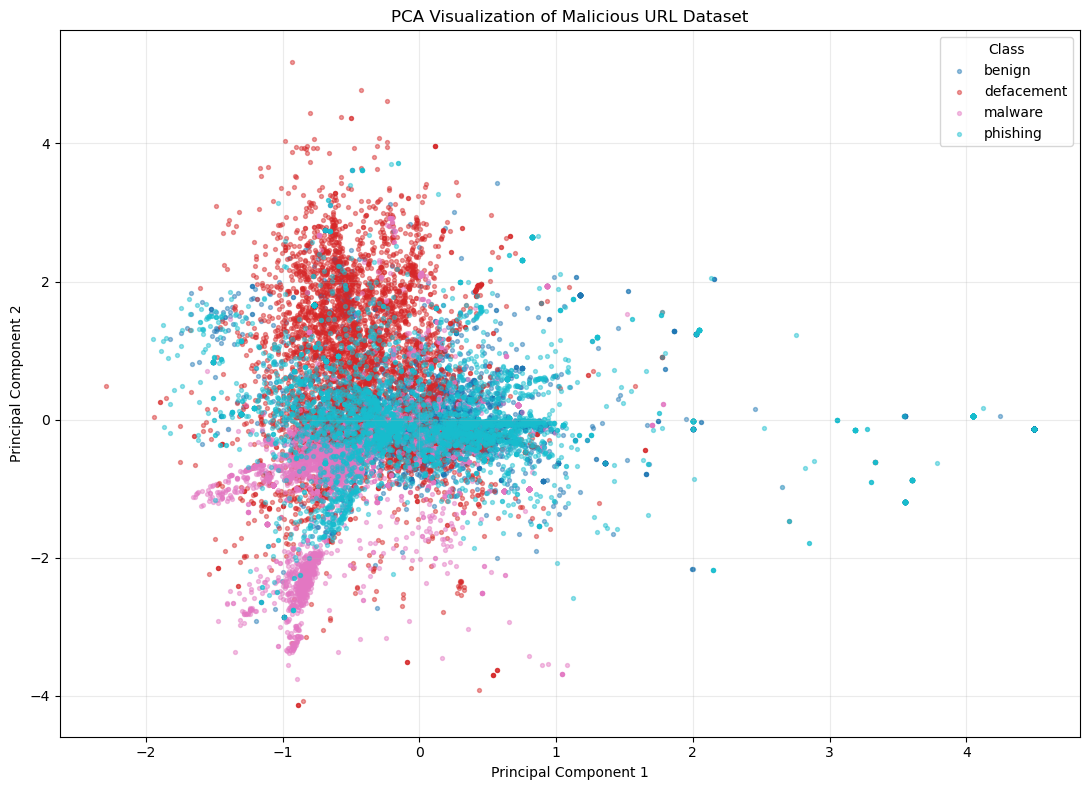


Saved: pca_url_classification_result.png


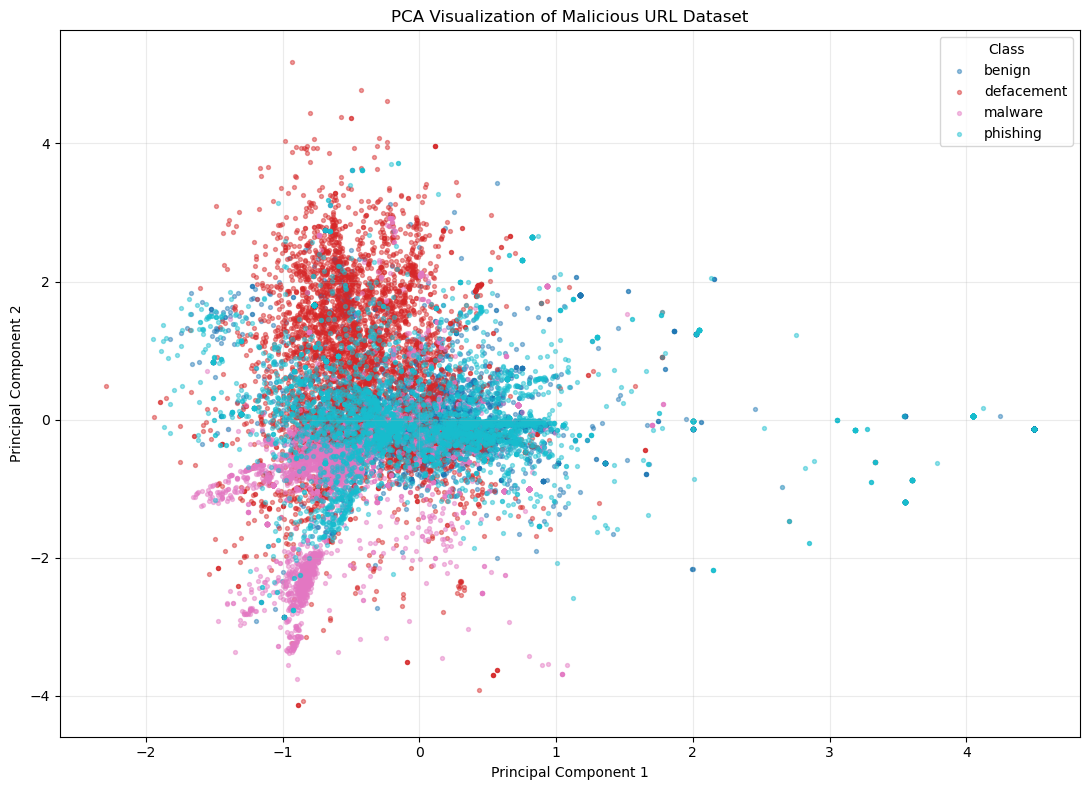

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.parse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# =========================
# Config
# =========================

DATA_PATH = "./malicious_phish.csv"
URL_COL = "url"
LABEL_COL = "type"

SAMPLE_PER_CLASS = 5000
RANDOM_STATE = 42

MAX_TFIDF_FEATURES = 30000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

SVD_COMPONENTS = 50


# =========================
# Safe tokenizer
# =========================

def clean_url_text(url):
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    url = url.replace("[", "").replace("]", "")
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    text = clean_url_text(text)
    parts = re.split(r"[^a-zA-Z0-9]+", text)
    return [p for p in parts if len(p) >= 2]


def safe_parse_url(url):
    cleaned = clean_url_text(url)

    try:
        parse_target = cleaned

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", parse_target):
            parse_target = "http://" + parse_target

        return urllib.parse.urlparse(parse_target)

    except Exception:
        return None


def tokenize_url_simple(url):
    try:
        u = clean_url_text(url)
        parsed = safe_parse_url(u)

        tokens = []

        if parsed is None:
            return split_by_separators(u)

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        if ":" in host:
            host = host.split(":")[0]

        if host.startswith("www."):
            host = host[4:]

        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tokens.append("tld_" + domain_parts[-1])

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 2:
                    tokens.append("sld_" + part)
                elif idx < len(domain_parts) - 2:
                    tokens.append("subdomain_" + part)

                tokens.append("domain_" + part)
                tokens.extend(split_by_separators(part))

        for seg in path.split("/"):
            if seg:
                tokens.append("path_" + seg)
                tokens.extend(split_by_separators(seg))

        if query:
            tokens.append("has_query")
            tokens.extend(split_by_separators(query))

        tokens.extend(split_by_separators(u))

        if "-" in u:
            tokens.append("has_hyphen")
        if "_" in u:
            tokens.append("has_underscore")
        if "%" in u:
            tokens.append("has_percent_encoding")
        if u.count(".") >= 4:
            tokens.append("many_dots")
        if len(u) >= 100:
            tokens.append("very_long_url")
        if re.search(r"\d{1,3}(\.\d{1,3}){3}", u):
            tokens.append("host_or_url_has_ip")

        return tokens if tokens else ["empty_url"]

    except Exception:
        return ["tokenizer_error"]


# =========================
# Load dataset
# =========================

df = pd.read_csv(DATA_PATH)
df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Original shape:", df.shape)
print("\nOriginal label distribution:")
print(df[LABEL_COL].value_counts())


# =========================
# Stratified sampling
# =========================

sampled_parts = []

for label, group in df.groupby(LABEL_COL):
    n = min(SAMPLE_PER_CLASS, len(group))
    sampled_parts.append(group.sample(n=n, random_state=RANDOM_STATE))

sample_df = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nSample shape:", sample_df.shape)
print("\nSample label distribution:")
print(sample_df[LABEL_COL].value_counts())


# =========================
# TF-IDF vectorization
# =========================

vectorizer = TfidfVectorizer(
    tokenizer=tokenize_url_simple,
    token_pattern=None,
    lowercase=False,
    max_features=MAX_TFIDF_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF
)

X_tfidf = vectorizer.fit_transform(sample_df[URL_COL].tolist())

print("\nTF-IDF shape:", X_tfidf.shape)


# =========================
# Sparse reduction: TruncatedSVD
# =========================

svd = TruncatedSVD(
    n_components=SVD_COMPONENTS,
    random_state=RANDOM_STATE
)

X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)
print("SVD explained variance ratio sum:", round(svd.explained_variance_ratio_.sum(), 4))


# =========================
# PCA 2D
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svd)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("PCA explained variance ratio sum:", round(pca.explained_variance_ratio_.sum(), 4))


# =========================
# Silhouette score
# =========================

labels = sample_df[LABEL_COL].values

try:
    sil = silhouette_score(X_pca, labels)
    print("\nSilhouette score on PCA 2D:", round(sil, 4))
except Exception as e:
    print("\nSilhouette score failed:", e)


# =========================
# Plot
# =========================

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": labels
})

plt.figure(figsize=(11, 8))

classes = sorted(plot_df["label"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for cls, color in zip(classes, colors):
    part = plot_df[plot_df["label"] == cls]
    plt.scatter(
        part["PC1"],
        part["PC2"],
        s=8,
        alpha=0.45,
        label=cls,
        color=color
    )

plt.title("PCA Visualization of Malicious URL Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# =========================
# Optional: save image
# =========================

plt.figure(figsize=(11, 8))

for cls, color in zip(classes, colors):
    part = plot_df[plot_df["label"] == cls]
    plt.scatter(
        part["PC1"],
        part["PC2"],
        s=8,
        alpha=0.45,
        label=cls,
        color=color
    )

plt.title("PCA Visualization of Malicious URL Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("pca_url_classification_result.png", dpi=300)
print("\nSaved: pca_url_classification_result.png")


Original shape: (651191, 2)

Original label distribution:
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: type, dtype: int64

Sample shape: (12000, 2)

Sample label distribution:
benign        3000
malware       3000
phishing      3000
defacement    3000
Name: type, dtype: int64

TF-IDF shape: (12000, 7108)
SVD shape: (12000, 50)
SVD explained variance: 0.3313

Silhouette score on t-SNE 2D: 0.0311


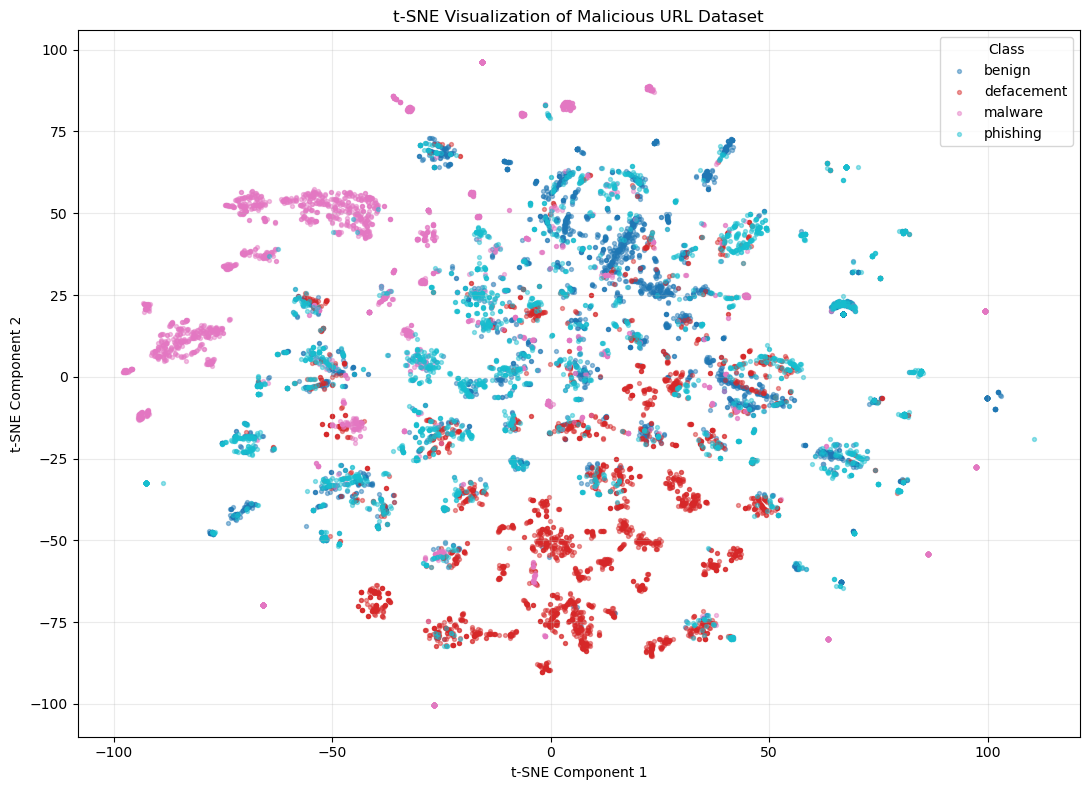


Saved: tsne_url_classification_result.png


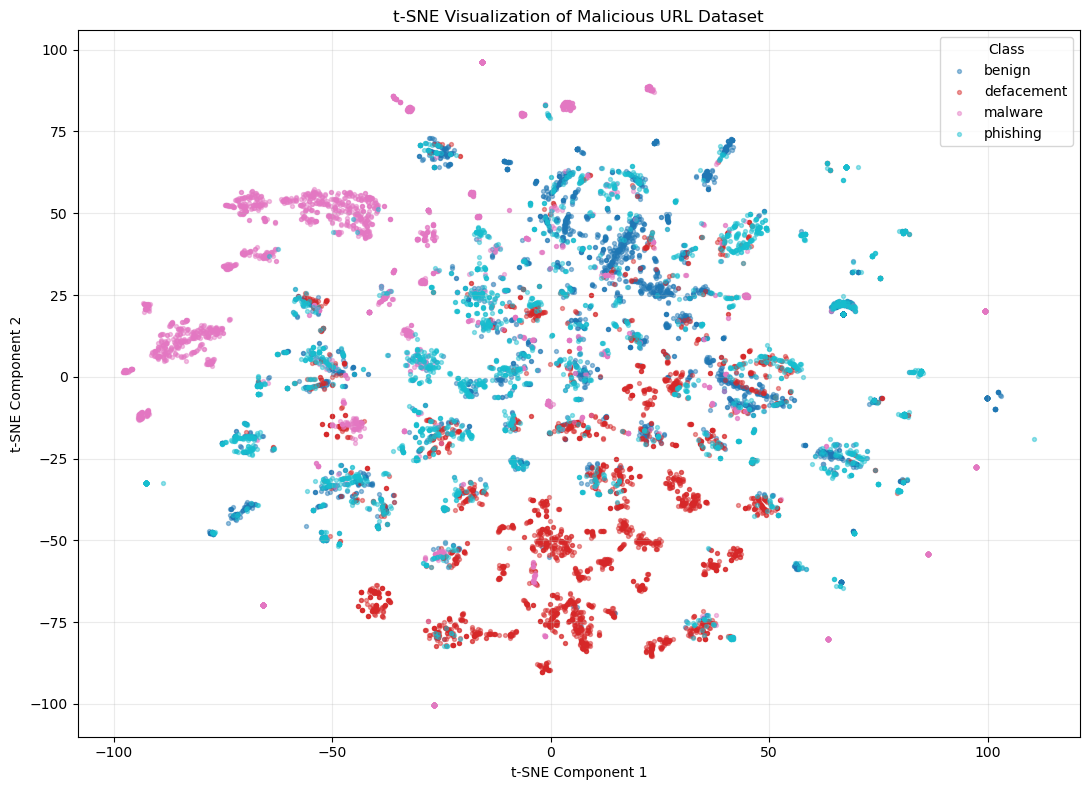

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.parse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


# =========================
# Config
# =========================

DATA_PATH = "./malicious_phish.csv"
URL_COL = "url"
LABEL_COL = "type"

SAMPLE_PER_CLASS = 3000
RANDOM_STATE = 42

MAX_TFIDF_FEATURES = 30000
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

SVD_COMPONENTS = 50


# =========================
# Safe tokenizer
# =========================

def clean_url_text(url):
    if url is None:
        url = ""

    url = str(url).strip().lower()

    try:
        url = urllib.parse.unquote(url, errors="ignore")
    except Exception:
        pass

    url = url.replace("[", "").replace("]", "")
    url = re.sub(r"[\x00-\x1f\x7f]", "", url)

    return url


def split_by_separators(text):
    text = clean_url_text(text)
    return [p for p in re.split(r"[^a-zA-Z0-9]+", text) if len(p) >= 2]


def safe_parse_url(url):
    cleaned = clean_url_text(url)

    try:
        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\-.]*://", cleaned):
            cleaned = "http://" + cleaned

        return urllib.parse.urlparse(cleaned)

    except Exception:
        return None


def tokenize_url_simple(url):
    try:
        u = clean_url_text(url)
        parsed = safe_parse_url(u)

        tokens = []

        if parsed is None:
            return split_by_separators(u)

        host = parsed.netloc.lower() if parsed.netloc else ""
        path = parsed.path.lower() if parsed.path else ""
        query = parsed.query.lower() if parsed.query else ""

        if "@" in host:
            tokens.append("has_userinfo")
            host = host.split("@")[-1]

        if ":" in host:
            host = host.split(":")[0]

        if host.startswith("www."):
            host = host[4:]

        domain_parts = [p for p in host.split(".") if p]

        if domain_parts:
            tokens.append("tld_" + domain_parts[-1])

            for idx, part in enumerate(domain_parts):
                if idx == len(domain_parts) - 2:
                    tokens.append("sld_" + part)
                elif idx < len(domain_parts) - 2:
                    tokens.append("subdomain_" + part)

                tokens.append("domain_" + part)
                tokens.extend(split_by_separators(part))

        for seg in path.split("/"):
            if seg:
                tokens.append("path_" + seg)
                tokens.extend(split_by_separators(seg))

        if query:
            tokens.append("has_query")
            tokens.extend(split_by_separators(query))

        tokens.extend(split_by_separators(u))

        if "-" in u:
            tokens.append("has_hyphen")
        if "_" in u:
            tokens.append("has_underscore")
        if "%" in u:
            tokens.append("has_percent_encoding")
        if u.count(".") >= 4:
            tokens.append("many_dots")
        if len(u) >= 100:
            tokens.append("very_long_url")
        if re.search(r"\d{1,3}(\.\d{1,3}){3}", u):
            tokens.append("host_or_url_has_ip")

        return tokens if tokens else ["empty_url"]

    except Exception:
        return ["tokenizer_error"]


# =========================
# Load dataset
# =========================

df = pd.read_csv(DATA_PATH)
df = df[[URL_COL, LABEL_COL]].dropna()
df[URL_COL] = df[URL_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Original shape:", df.shape)
print("\nOriginal label distribution:")
print(df[LABEL_COL].value_counts())


# =========================
# Stratified sampling
# =========================

sampled_parts = []

for label, group in df.groupby(LABEL_COL):
    n = min(SAMPLE_PER_CLASS, len(group))
    sampled_parts.append(group.sample(n=n, random_state=RANDOM_STATE))

sample_df = pd.concat(sampled_parts, axis=0)
sample_df = sample_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nSample shape:", sample_df.shape)
print("\nSample label distribution:")
print(sample_df[LABEL_COL].value_counts())


# =========================
# TF-IDF vectorization
# =========================

vectorizer = TfidfVectorizer(
    tokenizer=tokenize_url_simple,
    token_pattern=None,
    lowercase=False,
    max_features=MAX_TFIDF_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF
)

X_tfidf = vectorizer.fit_transform(sample_df[URL_COL].tolist())

print("\nTF-IDF shape:", X_tfidf.shape)


# =========================
# Sparse reduction: TruncatedSVD
# =========================

svd = TruncatedSVD(
    n_components=SVD_COMPONENTS,
    random_state=RANDOM_STATE
)

X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)
print("SVD explained variance:", round(svd.explained_variance_ratio_.sum(), 4))


# =========================
# t-SNE 2D
# =========================

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    init="pca",
    random_state=RANDOM_STATE,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_svd)

labels = sample_df[LABEL_COL].values

try:
    sil = silhouette_score(X_tsne, labels)
    print("\nSilhouette score on t-SNE 2D:", round(sil, 4))
except Exception as e:
    print("\nSilhouette score failed:", e)


# =========================
# Plot
# =========================

plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "label": labels
})

plt.figure(figsize=(11, 8))

classes = sorted(plot_df["label"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for cls, color in zip(classes, colors):
    part = plot_df[plot_df["label"] == cls]

    plt.scatter(
        part["TSNE1"],
        part["TSNE2"],
        s=8,
        alpha=0.45,
        label=cls,
        color=color
    )

plt.title("t-SNE Visualization of Malicious URL Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# =========================
# Save image
# =========================

plt.figure(figsize=(11, 8))

for cls, color in zip(classes, colors):
    part = plot_df[plot_df["label"] == cls]

    plt.scatter(
        part["TSNE1"],
        part["TSNE2"],
        s=8,
        alpha=0.45,
        label=cls,
        color=color
    )

plt.title("t-SNE Visualization of Malicious URL Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("tsne_url_classification_result.png", dpi=300)

print("\nSaved: tsne_url_classification_result.png")
